# ⚡ Pokémon TCG AI Battle — Meta Snapshot: 18 July

## Spidops and Festival Challenge the Alakazam–Crustle Core

**Field window: July 10–16, 2026**

> Alakazam remained the field center, but the pressure around it changed sharply: Team Rocket Spidops and Festival surged, Crustle lost ground, and Starmie produced the strongest exact-list signal. The week again showed that finding a powerful 60-card list is easier than reproducing the policy that makes it powerful.

In [1]:
import base64, glob, importlib.util, io, json, os, shutil, sys, tarfile, py_compile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from IPython.display import display, Markdown

plt.rcParams.update({
    'figure.dpi': 135,
    'savefig.dpi': 170,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.labelcolor': '#243447',
    'xtick.color': '#243447',
    'ytick.color': '#243447',
    'font.size': 10,
    'axes.grid': True,
    'grid.alpha': 0.18,
})

TREND_CSV = "date,archetype,games,wins,draws,score_rate,wilson_low,wilson_high,usage_share\n20260710,alakazam_dunsparce,4160,2132,0,0.5125,0.497306,0.527671,0.39800995024875624\n20260710,crustle,2218,1154,0,0.520289,0.49948,0.541027,0.21220818982013012\n20260710,other:Marnie's Impidimp|Munkidori,678,276,0,0.40708,0.370723,0.444484,0.06486796785304248\n20260710,other:Marnie's Grimmsnarl ex|Marnie's Impidimp,581,302,1,0.520654,0.480029,0.561008,0.05558744737849215\n20260710,starmie,580,312,1,0.538793,0.498101,0.578975,0.05549177190968236\n20260710,other:Cynthia's Gabite|Cynthia's Gible,570,306,0,0.536842,0.495796,0.577395,0.05453501722158439\n20260710,lucario,252,96,0,0.380952,0.323206,0.442274,0.024110218140068886\n20260710,dragapult,241,123,0,0.510373,0.447594,0.572828,0.023057787983161118\n20260710,archaludon,197,78,0,0.395939,0.330263,0.465596,0.018848067355530043\n20260710,other:Comfey|Bramblin,187,118,0,0.631016,0.559867,0.696891,0.01789131266743207\n20260710,other:Mega Kangaskhan ex|Meowth ex,167,78,0,0.467066,0.392988,0.542624,0.015977803291236128\n20260710,team_rocket_spidops,145,82,0,0.565517,0.484173,0.643479,0.01387294297742059\n20260710,other:Comfey|Handheld Fan,127,40,0,0.314961,0.240616,0.400171,0.01215078453884424\n20260710,other:Comfey|Chandelure[ID:98],122,45,0,0.368852,0.288459,0.457253,0.011672407194795254\n20260710,other:N’s Zoroark ex|N’s Zorua,48,21,0,0.4375,0.307011,0.577252,0.004592422502870264\n20260710,other:Gravity Gemstone|Cubchoo,46,12,0,0.26087,0.156007,0.402594,0.0044010715652506695\n20260710,other:Air Balloon|Mega Lopunny ex,40,19,0,0.475,0.329352,0.625029,0.003827018752391887\n20260710,other:Solrock|Okidogi[ID:116],35,15,0,0.428571,0.279843,0.591429,0.003348641408342901\n20260710,other:Cynthia's Power Weight|Cynthia's Gabite,23,10,0,0.434783,0.256344,0.63189,0.0022005357826253348\n20260710,other:Cubchoo|Gravity Gemstone,11,1,0,0.090909,0.016232,0.377365,0.001052430156907769\n20260710,other:Marnie's Grimmsnarl ex|Marnie's Morgrem,9,4,0,0.444444,0.188775,0.733353,0.0008610792192881745\n20260710,other:Team Rocket's Honchkrow|Team Rocket's Murkrow,5,0,0,0.0,0.0,0.434491,0.00047837734404898585\n20260710,other:Cubchoo|Dunsparce[ID:65],3,1,0,0.333333,0.06149,0.792345,0.0002870264064293915\n20260710,other:Cubchoo|Shaymin[ID:343],3,0,0,0.0,0.0,0.561506,0.0002870264064293915\n20260710,other:Mega Froslass ex|Snorunt[ID:860],3,0,0,0.0,0.0,0.561506,0.0002870264064293915\n20260710,other:Air Balloon|Buneary[ID:848],1,0,0,0.0,0.0,0.793457,9.567546880979717e-05\n20260711,alakazam_dunsparce,3721,1827,0,0.490997,0.474952,0.507061,0.37076524511757675\n20260711,crustle,2483,1355,0,0.545711,0.526071,0.56521,0.24740932642487046\n20260711,other:Cynthia's Gabite|Cynthia's Gible,609,300,0,0.492611,0.453075,0.53224,0.06068154643284177\n20260711,dragapult,560,311,0,0.555357,0.513961,0.595999,0.05579912315663611\n20260711,other:Marnie's Impidimp|Munkidori,556,219,0,0.393885,0.354132,0.435094,0.055400557991231565\n20260711,other:Marnie's Grimmsnarl ex|Marnie's Impidimp,401,205,0,0.511222,0.462421,0.559809,0.0399561578318055\n20260711,team_rocket_spidops,348,202,0,0.58046,0.528009,0.631154,0.0346751693901953\n20260711,lucario,342,128,0,0.374269,0.324643,0.426689,0.03407732164208848\n20260711,other:Comfey|Bramblin,235,127,0,0.540426,0.476568,0.602983,0.023415703467516938\n20260711,starmie,222,107,0,0.481982,0.417119,0.547458,0.022120366679952173\n20260711,other:Gravity Gemstone|Cubchoo,143,64,0,0.447552,0.368486,0.529363,0.014248704663212436\n20260711,archaludon,84,33,0,0.392857,0.295302,0.499784,0.008369868473495417\n20260711,other:Comfey|Handheld Fan,68,27,0,0.397059,0.289285,0.515842,0.006775607811877242\n20260711,other:Air Balloon|Mega Lopunny ex,67,33,0,0.492537,0.37652,0.609364,0.006675966520526106\n20260711,other:Cynthia's Power Weight|Cynthia's Gabite,44,18,0,0.409091,0.276876,0.555905,0.00438421681944998\n20260711,other:Comfey|Brambleghast,36,12,0,0.333333,0.202144,0.496663,0.0035870864886408927\n20260711,other:N’s Zoroark ex|N’s Zorua,25,17,0,0.68,0.484099,0.82795,0.0024910322837783977\n20260711,other:Mega Kangaskhan ex|Meowth ex,25,8,0,0.32,0.17205,0.515901,0.0024910322837783977\n20260711,other:Solrock|Okidogi[ID:116],24,10,0,0.416667,0.244673,0.611657,0.0023913909924272616\n20260711,other:Cubchoo|Shaymin[ID:343],13,5,0,0.384615,0.177094,0.644775,0.0012953367875647669\n20260711,other:Team Rocket's Honchkrow|Team Rocket's Murkrow,8,3,0,0.375,0.136842,0.694262,0.0007971303308090873\n20260711,other:Mega Froslass ex|Snorunt[ID:860],7,2,0,0.285714,0.082217,0.641071,0.0006974890394579514\n20260711,other:Comfey|Chandelure[ID:98],6,2,0,0.333333,0.096769,0.700012,0.0005978477481068154\n20260711,other:Cubchoo|Dunsparce[ID:65],5,2,0,0.4,0.117618,0.76928,0.0004982064567556796\n20260711,hop_trevenant,3,1,0,0.333333,0.06149,0.792345,0.0002989238740534077\n20260711,other:Comfey|Gravity Gemstone,1,0,0,0.0,0.0,0.793457,9.964129135113592e-05\n20260712,alakazam_dunsparce,3609,1797,0,0.497922,0.48162,0.514228,0.3573267326732673\n20260712,crustle,2833,1426,0,0.503353,0.48495,0.521748,0.2804950495049505\n20260712,other:Cynthia's Gabite|Cynthia's Gible,555,285,0,0.513514,0.47198,0.554861,0.05495049504950495\n20260712,dragapult,499,240,0,0.480962,0.437436,0.524779,0.04940594059405941\n20260712,other:Marnie's Grimmsnarl ex|Marnie's Impidimp,479,249,0,0.519833,0.475111,0.564239,0.047425742574257426\n20260712,other:Marnie's Impidimp|Munkidori,476,203,0,0.426471,0.382804,0.471315,0.04712871287128713\n20260712,team_rocket_spidops,451,285,0,0.631929,0.586478,0.675151,0.04465346534653465\n20260712,starmie,403,225,0,0.558313,0.509504,0.60602,0.0399009900990099\n20260712,other:Gravity Gemstone|Cubchoo,146,74,0,0.506849,0.426622,0.586725,0.014455445544554456\n20260712,other:Comfey|Bramblin,146,68,0,0.465753,0.386756,0.546507,0.014455445544554456\n20260712,archaludon,117,43,0,0.367521,0.285667,0.457799,0.011584158415841584\n20260712,lucario,107,38,0,0.35514,0.270928,0.449394,0.010594059405940595\n20260712,other:Air Balloon|Mega Lopunny ex,101,52,0,0.514851,0.418638,0.609977,0.01\n20260712,other:Comfey|Handheld Fan,72,34,0,0.472222,0.361263,0.585995,0.007128712871287129\n20260712,other:Cubchoo|Shaymin[ID:343],30,12,0,0.4,0.245904,0.576799,0.0029702970297029703\n20260712,other:Ralts|Mega Gardevoir ex,25,9,0,0.36,0.202477,0.554818,0.0024752475247524753\n20260712,other:Cynthia's Power Weight|Cynthia's Gabite,12,2,0,0.166667,0.046964,0.448036,0.001188118811881188\n20260712,other:N’s Zoroark ex|N’s Zorua,10,4,0,0.4,0.168178,0.68733,0.0009900990099009901\n20260712,other:Team Rocket's Honchkrow|Team Rocket's Murkrow,6,2,0,0.333333,0.096769,0.700012,0.000594059405940594\n20260712,other:Air Balloon|Buneary[ID:848],6,1,0,0.166667,0.030053,0.563509,0.000594059405940594\n20260712,other:Mega Kangaskhan ex|Meowth ex,6,0,0,0.0,0.0,0.390343,0.000594059405940594\n20260712,other:Solrock|Okidogi[ID:116],4,1,0,0.25,0.045586,0.699364,0.00039603960396039607\n20260712,other:Mega Froslass ex|Snorunt[ID:860],4,0,0,0.0,0.0,0.4899,0.00039603960396039607\n20260712,other:Comfey|Brambleghast,2,0,0,0.0,0.0,0.657628,0.00019801980198019803\n20260712,festival_thwackey,1,0,0,0.0,0.0,0.793457,9.900990099009902e-05\n20260713,alakazam_dunsparce,4400,2204,1,0.501023,0.486254,0.515789,0.43659456241317723\n20260713,crustle,2226,1096,0,0.492363,0.471625,0.513127,0.22087715816630285\n20260713,other:Marnie's Impidimp|Munkidori,1059,546,3,0.516997,0.486893,0.546979,0.10508037308989879\n20260713,starmie,736,388,0,0.527174,0.491056,0.563009,0.0730303631672951\n20260713,team_rocket_spidops,510,293,0,0.57451,0.531199,0.616706,0.050605278825163726\n20260713,other:Marnie's Grimmsnarl ex|Marnie's Impidimp,385,195,0,0.506494,0.456735,0.556123,0.038202024211153006\n20260713,other:Cynthia's Gabite|Cynthia's Gible,197,79,0,0.401015,0.3351,0.470717,0.01954752927168089\n20260713,dragapult,187,86,0,0.459893,0.389985,0.531416,0.018555268902560033\n20260713,archaludon,140,58,0,0.414286,0.33604,0.497109,0.013891645167692002\n20260713,other:Gravity Gemstone|Cubchoo,50,22,0,0.44,0.31162,0.576942,0.004961301845604287\n20260713,other:Comfey|Handheld Fan,46,9,0,0.195652,0.106505,0.331715,0.0045643976979559435\n20260713,other:Air Balloon|Mega Lopunny ex,40,20,0,0.5,0.351993,0.648007,0.0039690414764834295\n20260713,lucario,27,10,0,0.37037,0.215323,0.557711,0.002679102996626315\n20260713,other:Cynthia's Power Weight|Cynthia's Gabite,20,8,0,0.4,0.218804,0.613422,0.0019845207382417148\n20260713,other:Air Balloon|Buneary[ID:848],19,8,0,0.421053,0.231416,0.637244,0.001885294701329629\n20260713,other:Solrock|Okidogi[ID:116],14,5,0,0.357143,0.163445,0.61236,0.0013891645167692002\n20260713,other:Team Rocket's Honchkrow|Team Rocket's Murkrow,10,5,0,0.5,0.23659,0.76341,0.0009922603691208574\n20260713,festival_thwackey,6,2,0,0.333333,0.096769,0.700012,0.0005953562214725144\n20260713,other:Mega Kangaskhan ex|Meowth ex,2,2,0,1.0,0.342372,1.0,0.00019845207382417147\n20260713,other:N’s Zoroark ex|N’s Zorua,2,0,0,0.0,0.0,0.657628,0.00019845207382417147\n20260713,other:Ralts|Mega Gardevoir ex,1,1,0,1.0,0.206543,1.0,9.922603691208574e-05\n20260713,other:Mega Froslass ex|Snorunt[ID:860],1,0,0,0.0,0.0,0.793457,9.922603691208574e-05\n20260714,alakazam_dunsparce,4579,2306,1,0.503713,0.489234,0.518185,0.4644958409413674\n20260714,crustle,2338,1205,1,0.515612,0.495345,0.535827,0.23716778251166565\n20260714,other:Marnie's Impidimp|Munkidori,1165,549,1,0.471674,0.443148,0.500386,0.11817812943801988\n20260714,starmie,617,314,1,0.509724,0.470341,0.548988,0.06258876039764658\n20260714,festival_thwackey,492,257,0,0.522358,0.478218,0.566151,0.04990870359099209\n20260714,team_rocket_spidops,252,135,0,0.535714,0.474063,0.596293,0.02556299452221546\n20260714,other:Marnie's Grimmsnarl ex|Marnie's Impidimp,210,87,0,0.414286,0.349783,0.481868,0.02130249543517955\n20260714,other:Cynthia's Gabite|Cynthia's Gible,72,30,0,0.416667,0.30985,0.531925,0.007303712720632989\n20260714,lucario,40,14,0,0.35,0.221343,0.504944,0.004057618178129438\n20260714,dragapult,29,10,0,0.344828,0.199405,0.526552,0.0029417731791438425\n20260714,other:Ralts|Mega Gardevoir ex,27,9,0,0.333333,0.186431,0.521756,0.002738892270237371\n20260714,archaludon,16,5,0,0.3125,0.141644,0.555961,0.0016230472712517752\n20260714,other:Cynthia's Power Weight|Cynthia's Gabite,10,2,0,0.2,0.056681,0.509843,0.0010144045445323595\n20260714,other:Comfey|Handheld Fan,5,2,0,0.4,0.117618,0.76928,0.0005072022722661798\n20260714,other:Okidogi[ID:116]|Solrock,2,2,0,1.0,0.342372,1.0,0.0002028809089064719\n20260714,other:Mega Kangaskhan ex|Meowth ex,1,0,0,0.0,0.0,0.793457,0.00010144045445323595\n20260714,other:Gravity Gemstone|Cubchoo,1,0,0,0.0,0.0,0.793457,0.00010144045445323595\n20260714,other:Air Balloon|Buneary[ID:848],1,0,0,0.0,0.0,0.793457,0.00010144045445323595\n20260714,other:Mega Sharpedo ex|Carvanha,1,0,0,0.0,0.0,0.793457,0.00010144045445323595\n20260715,alakazam_dunsparce,4028,1972,0,0.489573,0.474152,0.505013,0.41740932642487044\n20260715,crustle,1944,939,4,0.484053,0.461891,0.506279,0.20145077720207255\n20260715,team_rocket_spidops,1111,594,4,0.536454,0.507055,0.565601,0.11512953367875647\n20260715,other:Marnie's Impidimp|Munkidori,780,384,0,0.492308,0.457346,0.527345,0.08082901554404145\n20260715,festival_thwackey,697,405,0,0.581062,0.544086,0.617149,0.0722279792746114\n20260715,starmie,401,201,0,0.501247,0.452529,0.549941,0.04155440414507772\n20260715,other:Marnie's Grimmsnarl ex|Marnie's Impidimp,375,184,0,0.490667,0.44042,0.541102,0.038860103626943004\n20260715,other:Cynthia's Gabite|Cynthia's Gible,197,96,0,0.48731,0.418423,0.556682,0.020414507772020727\n20260715,lucario,67,28,0,0.41791,0.307421,0.537303,0.00694300518134715\n20260715,archaludon,35,15,0,0.428571,0.279843,0.591429,0.003626943005181347\n20260715,other:Ralts|Mega Gardevoir ex,3,1,0,0.333333,0.06149,0.792345,0.000310880829015544\n20260715,other:Mega Kangaskhan ex|Meowth ex,3,0,0,0.0,0.0,0.561506,0.000310880829015544\n20260715,other:Mega Sharpedo ex|Carvanha,3,0,0,0.0,0.0,0.561506,0.000310880829015544\n20260715,other:Okidogi[ID:116]|Solrock,2,1,0,0.5,0.094529,0.905471,0.0002072538860103627\n20260715,other:Gravity Gemstone|Cubchoo,2,1,0,0.5,0.094529,0.905471,0.0002072538860103627\n20260715,dragapult,2,0,0,0.0,0.0,0.657628,0.0002072538860103627\n20260716,alakazam_dunsparce,3781,1896,0,0.501455,0.485524,0.517383,0.39716386554621846\n20260716,crustle,1859,868,2,0.467456,0.444865,0.490181,0.19527310924369748\n20260716,team_rocket_spidops,1174,613,1,0.522572,0.493973,0.551025,0.12331932773109244\n20260716,other:Marnie's Impidimp|Munkidori,945,489,1,0.517989,0.486122,0.549711,0.09926470588235294\n20260716,starmie,424,233,0,0.549528,0.501936,0.596232,0.04453781512605042\n20260716,other:Cynthia's Gabite|Cynthia's Gible,422,209,0,0.495261,0.447816,0.542791,0.04432773109243698\n20260716,festival_thwackey,405,216,0,0.533333,0.48466,0.581381,0.04254201680672269\n20260716,dragapult,240,119,0,0.495833,0.433143,0.558655,0.025210084033613446\n20260716,other:Marnie's Grimmsnarl ex|Marnie's Impidimp,156,70,0,0.448718,0.372835,0.527066,0.01638655462184874\n20260716,archaludon,54,22,0,0.407407,0.28678,0.540334,0.005672268907563025\n20260716,lucario,31,12,0,0.387097,0.237329,0.561762,0.0032563025210084035\n20260716,other:N’s Zoroark ex|N’s Zorua,22,9,0,0.409091,0.232556,0.612655,0.002310924369747899\n20260716,other:Ralts|Mega Gardevoir ex,3,1,0,0.333333,0.06149,0.792345,0.0003151260504201681\n20260716,other:Comfey|Handheld Fan,2,1,0,0.5,0.094529,0.905471,0.0002100840336134454\n20260716,other:Air Balloon|Buneary[ID:848],1,0,0,0.0,0.0,0.793457,0.0001050420168067227\n20260716,other:Cubchoo|Gravity Gemstone,1,0,0,0.0,0.0,0.793457,0.0001050420168067227\n"
CURRENT_CSV = "archetype,games,wins,draws,score_rate,wilson_low,wilson_high,usage_share\nalakazam_dunsparce,3781,1896,0,0.501455,0.485524,0.517383,0.39716386554621846\ncrustle,1859,868,2,0.467456,0.444865,0.490181,0.19527310924369748\nteam_rocket_spidops,1174,613,1,0.522572,0.493973,0.551025,0.12331932773109244\nother:Marnie's Impidimp|Munkidori,945,489,1,0.517989,0.486122,0.549711,0.09926470588235294\nstarmie,424,233,0,0.549528,0.501936,0.596232,0.04453781512605042\nother:Cynthia's Gabite|Cynthia's Gible,422,209,0,0.495261,0.447816,0.542791,0.04432773109243698\nfestival_thwackey,405,216,0,0.533333,0.48466,0.581381,0.04254201680672269\ndragapult,240,119,0,0.495833,0.433143,0.558655,0.025210084033613446\nother:Marnie's Grimmsnarl ex|Marnie's Impidimp,156,70,0,0.448718,0.372835,0.527066,0.01638655462184874\narchaludon,54,22,0,0.407407,0.28678,0.540334,0.005672268907563025\nlucario,31,12,0,0.387097,0.237329,0.561762,0.0032563025210084035\nother:N’s Zoroark ex|N’s Zorua,22,9,0,0.409091,0.232556,0.612655,0.002310924369747899\nother:Ralts|Mega Gardevoir ex,3,1,0,0.333333,0.06149,0.792345,0.0003151260504201681\nother:Comfey|Handheld Fan,2,1,0,0.5,0.094529,0.905471,0.0002100840336134454\nother:Air Balloon|Buneary[ID:848],1,0,0,0.0,0.0,0.793457,0.0001050420168067227\nother:Cubchoo|Gravity Gemstone,1,0,0,0.0,0.0,0.793457,0.0001050420168067227\n"
MATCHUP_CSV = "archetype_a,archetype_b,games,a_wins,b_wins,draws,a_score_rate\nalakazam_dunsparce,crustle,757,391,366,0,0.5165125495376486\nalakazam_dunsparce,alakazam_dunsparce,710,401,309,0,0.5647887323943662\nalakazam_dunsparce,team_rocket_spidops,510,233,277,0,0.4568627450980392\nalakazam_dunsparce,other:Marnie's Impidimp|Munkidori,392,176,216,0,0.4489795918367347\ncrustle,team_rocket_spidops,247,96,150,1,0.39068825910931176\ncrustle,other:Marnie's Impidimp|Munkidori,191,97,93,1,0.5104712041884817\nalakazam_dunsparce,starmie,173,103,70,0,0.5953757225433526\nalakazam_dunsparce,festival_thwackey,173,81,92,0,0.4682080924855491\nalakazam_dunsparce,other:Cynthia's Gabite|Cynthia's Gible,166,106,60,0,0.6385542168674698\ncrustle,crustle,144,83,61,0,0.5763888888888888\nother:Marnie's Impidimp|Munkidori,team_rocket_spidops,105,56,49,0,0.5333333333333333\ncrustle,other:Cynthia's Gabite|Cynthia's Gible,97,37,60,0,0.38144329896907214\nalakazam_dunsparce,dragapult,89,38,51,0,0.42696629213483145\ncrustle,starmie,81,25,56,0,0.30864197530864196\ncrustle,festival_thwackey,76,30,46,0,0.39473684210526316\ncrustle,dragapult,58,37,21,0,0.6379310344827587\nteam_rocket_spidops,team_rocket_spidops,55,39,16,0,0.7090909090909091\nalakazam_dunsparce,other:Marnie's Grimmsnarl ex|Marnie's Impidimp,54,24,30,0,0.4444444444444444\nfestival_thwackey,team_rocket_spidops,49,23,26,0,0.46938775510204084\nother:Cynthia's Gabite|Cynthia's Gible,team_rocket_spidops,49,28,21,0,0.5714285714285714\nstarmie,team_rocket_spidops,46,40,6,0,0.8695652173913043\ncrustle,other:Marnie's Grimmsnarl ex|Marnie's Impidimp,46,23,23,0,0.5\nother:Cynthia's Gabite|Cynthia's Gible,other:Marnie's Impidimp|Munkidori,44,30,14,0,0.6818181818181818\nother:Marnie's Impidimp|Munkidori,starmie,42,27,15,0,0.6428571428571429\nfestival_thwackey,other:Marnie's Impidimp|Munkidori,38,24,14,0,0.631578947368421\nother:Marnie's Impidimp|Munkidori,other:Marnie's Impidimp|Munkidori,37,15,22,0,0.40540540540540543\ndragapult,team_rocket_spidops,28,15,13,0,0.5357142857142857\ndragapult,other:Marnie's Impidimp|Munkidori,28,12,16,0,0.42857142857142855\nfestival_thwackey,starmie,26,2,24,0,0.07692307692307693\nother:Cynthia's Gabite|Cynthia's Gible,starmie,24,14,10,0,0.5833333333333334\nalakazam_dunsparce,archaludon,24,17,7,0,0.7083333333333334\nfestival_thwackey,other:Cynthia's Gabite|Cynthia's Gible,19,15,4,0,0.7894736842105263\ndragapult,starmie,16,5,11,0,0.3125\nother:Marnie's Grimmsnarl ex|Marnie's Impidimp,other:Marnie's Impidimp|Munkidori,15,7,8,0,0.4666666666666667\nalakazam_dunsparce,lucario,13,9,4,0,0.6923076923076923\nother:Marnie's Grimmsnarl ex|Marnie's Impidimp,team_rocket_spidops,11,1,10,0,0.09090909090909091\narchaludon,other:Marnie's Impidimp|Munkidori,10,4,6,0,0.4\nother:Cynthia's Gabite|Cynthia's Gible,other:Marnie's Grimmsnarl ex|Marnie's Impidimp,9,7,2,0,0.7777777777777778\nalakazam_dunsparce,other:N’s Zoroark ex|N’s Zorua,8,6,2,0,0.75\nfestival_thwackey,other:Marnie's Grimmsnarl ex|Marnie's Impidimp,8,7,1,0,0.875\narchaludon,crustle,7,2,5,0,0.2857142857142857\nlucario,team_rocket_spidops,7,4,3,0,0.5714285714285714\nother:N’s Zoroark ex|N’s Zorua,team_rocket_spidops,6,3,3,0,0.5\ndragapult,other:Cynthia's Gabite|Cynthia's Gible,6,5,1,0,0.8333333333333334\ndragapult,festival_thwackey,6,4,2,0,0.6666666666666666\ndragapult,other:Marnie's Grimmsnarl ex|Marnie's Impidimp,6,4,2,0,0.6666666666666666\narchaludon,team_rocket_spidops,5,5,0,0,1.0\ncrustle,other:N’s Zoroark ex|N’s Zorua,5,2,3,0,0.4\nother:Marnie's Grimmsnarl ex|Marnie's Impidimp,starmie,5,3,2,0,0.6\ncrustle,lucario,4,4,0,0,1.0\nstarmie,starmie,4,1,3,0,0.25\narchaludon,festival_thwackey,3,2,1,0,0.6666666666666666\nfestival_thwackey,lucario,3,1,2,0,0.3333333333333333\nother:Cynthia's Gabite|Cynthia's Gible,other:Cynthia's Gabite|Cynthia's Gible,3,1,2,0,0.3333333333333333\narchaludon,starmie,3,2,1,0,0.6666666666666666\nlucario,other:Marnie's Impidimp|Munkidori,3,2,1,0,0.6666666666666666\nother:Marnie's Impidimp|Munkidori,other:N’s Zoroark ex|N’s Zorua,2,1,1,0,0.5\nfestival_thwackey,other:N’s Zoroark ex|N’s Zorua,1,1,0,0,1.0\narchaludon,other:Cynthia's Gabite|Cynthia's Gible,1,0,1,0,0.0\nfestival_thwackey,festival_thwackey,1,0,1,0,0.0\nother:Ralts|Mega Gardevoir ex,team_rocket_spidops,1,1,0,0,1.0\nother:Comfey|Handheld Fan,other:Marnie's Impidimp|Munkidori,1,1,0,0,1.0\ncrustle,other:Comfey|Handheld Fan,1,1,0,0,1.0\nlucario,other:Cynthia's Gabite|Cynthia's Gible,1,0,1,0,0.0\nalakazam_dunsparce,other:Air Balloon|Buneary[ID:848],1,1,0,0,1.0\nfestival_thwackey,other:Ralts|Mega Gardevoir ex,1,1,0,0,1.0\nalakazam_dunsparce,other:Ralts|Mega Gardevoir ex,1,1,0,0,1.0\ndragapult,dragapult,1,0,1,0,0.0\ncrustle,other:Cubchoo|Gravity Gemstone,1,1,0,0,1.0\nother:Marnie's Grimmsnarl ex|Marnie's Impidimp,other:Marnie's Grimmsnarl ex|Marnie's Impidimp,1,1,0,0,1.0\narchaludon,dragapult,1,0,1,0,0.0\n"
CANDIDATE_CSV = 'candidate_id,candidate_archetype,panel_score,held_score,wilson_low,games,decision,role_note\nfactory_d1a413_p006_b8725949,starmie,0.8747,0.21875,0.155904,128,RESEARCH_ONLY_STRONG_PANEL_FAIL,Proxy score did not transfer to the independent strong-agent panel\npublic1084_lucario,lucario,0.6626,0.414062,0.33245,128,RESEARCH_ONLY_STRONG_PANEL_FAIL,"Mature reference, but below the current strong-panel leaders"\nlucifer19_battlecore_compact_agent_profile_a,archaludon,0.8016,0.580357,0.487783,112,RESEARCH_ROBUSTNESS_DERIVATIVE,Robust implementation on the same Archaludon deck; no edge over the selected policy\npublic_archaludon_75wr,archaludon,0.8634,0.598214,0.505619,112,RESEARCH_ONLY_NEAR_DUPLICATE,Strong single agent but highly correlated with the selected Archaludon policy\ni_have_one_rear_card,crustle,0.689798,0.571429,0.47891,112,CURRENT_SELECTOR_COMPLEMENT,Best differentiated complement in the independent strong-agent panel\nlive_a_archaludon_20260707,archaludon,0.863436,0.678571,0.587396,112,CURRENT_SELECTOR_LEADER,Highest independent strong-panel score and strength-adjusted rating\n'
PAIR_CSV = 'pair_key,mean_best_score_rate,pair_held_score,min_member_wilson_low,unique_edge_a,unique_edge_b,both_below_50_opponents,decision,policy_note\nlive_a_archaludon_20260707;i_have_one_rear_card,0.739583,0.651042,0.47891,2,1,0,SELECTED_PAIR_BY_USER_APPROVAL,Best diversified pair; both members contribute opponent-level edges\nlive_a_archaludon_20260707;public_archaludon_75wr,0.729167,0.65625,0.505619,2,0,0,RESEARCH_ONLY_CORRELATED_PAIR,High raw pair result but duplicated Metal-tempo failure risk\nlucifer19_battlecore_compact_agent_profile_a;i_have_one_rear_card,0.697917,0.578125,0.47891,3,2,0,RESEARCH_ALTERNATIVE,"Useful robustness alternative, but weaker than the selected Archaludon policy"\n'
TAIL_CSV = '''
candidate_id,tail_family,score_rate
public940_beam_lucario,top_meta_panel,0.806373
public940_beam_lucario,wilson_low,0.765245
policy_0003_beam_width2_low_deck_count6_search_max_candidates8,top_meta_panel,0.798077
policy_0003_beam_width2_low_deck_count6_search_max_candidates8,wilson_low,0.756853
public_crustle_aware_lucario,top_meta_panel,0.789216
public_crustle_aware_lucario,wilson_low,0.747034
live_b_alakazam_944,top_meta_panel,0.737981
live_b_alakazam_944,wilson_low,0.693684
'''
STRENGTH_CSV = "entity,raw_games,weighted_games,raw_score_rate,weighted_score_rate,strength_logit,strength_elo,opponent_strength_mean,opponent_strength_elo_mean,expected_vs_schedule,schedule_adjusted_residual,high_strength_games,high_strength_weighted_games,high_strength_score_rate,current_games,current_share,unique_decks,top_deck_hashes\nfestival_thwackey,1601,1343.069,0.549656,0.550589,0.561804,97.6,0.359955,62.5,0.550164,0.000425,1363,1140.087,0.530045,405,0.042542,4,2b28620093c61e6c4c7e5b345e7f783188f5746cc3bf77fbb39021cddf3f7b00;a7a5db860bd3da5cde3443ee141b88f4cbfdff46764797eea05a6a68107288ae;8b8154e3ff04b91809bf64a225ca40c6f8c60f66f32288b5cfd38684809a6dec\nteam_rocket_spidops,3991,3012.756,0.552744,0.54447,0.527628,91.7,0.349384,60.7,0.544309,0.00016,3303,2507.447,0.557032,1174,0.123319,9,0bd0c881e4ad4389372a62835f808fc82f63ae17b86712bfb1d8817a34425a7f;5b869def24c0ca5ed2b2bccba8d9e8198fb6146b94d1eacbf3471ca60b19f5af;225b6e216d5585974b3df3d8b81dbbd7cb409fd47be57b19e6cb69516219b70c\nother:Comfey|Bramblin,568,237.92,0.550176,0.541637,0.460841,80.1,0.300074,52.1,0.53976,0.001877,416,173.815,0.54804,0,0.0,2,eea0bff1e1f04f1803696022b2667a5378d55ed35fed33ba44bfd7916d86991b;a4922b65c102d14161b74ec373903ffbd42cf1aefe47d8940d3c5978030326ee\nstarmie,3383,2135.013,0.530003,0.529531,0.451354,78.4,0.333152,57.9,0.529326,0.000205,2625,1695.342,0.56362,424,0.044538,20,4a1d7a728a7322d418fd28245eef8a9e44add3371c693c314cbb9c7f09fd3855;5d41bdecc8879acbc6a7d17d00bffdfb26863147fca3e4d8198f2989addaa047;c234c419fb4934bac8e51c9ceea440d041dcc1bce76d4991c4caba48f4fc1d8b\nalakazam_dunsparce,28278,17861.998,0.499841,0.499185,0.340583,59.2,0.343637,59.7,0.499169,1.6e-05,22710,14531.428,0.494675,3781,0.397164,76,2cdddc6933305555b7280b32da402cab795e89890dbdabd5ca2fee420e9a654d;249d05fea2d041dc353da302e14cde9779b19122e8d3c13a12a1b87a547f4b87;0a43e4486fabb23d315cd04ec02cf9d84a2855c097e88a9e1863a649ffdbd83a\ncrustle,15901,9715.16,0.505251,0.498931,0.336084,58.4,0.340229,59.1,0.498889,4.2e-05,12612,7799.411,0.473155,1859,0.195273,32,ed9cdddb866dbaf9add2600e04edcdc30b7679a623ec2fa1cd13b55d4ce545bf;095da72a499e17e8970c166ad3a3be9874d98cfcb3c56219ca32689d9463130e;13aa401f18298345fd410d1581ed2f22f26b99a8a89428c31d7c3543e0e10bd4\ndragapult,1758,943.536,0.507679,0.501521,0.328687,57.1,0.323528,56.2,0.501162,0.000359,1333,731.092,0.489858,240,0.02521,19,138b82b48f26e7446ee8bb32e9fceedd1a4c90e825a00ff55e139ef2540a18a2;e21943131eb683fd0064b5b7cbe227aba950149dcf29c3a3f1b13663cd5efe8e;b780a2b15eaff6d23116923bf1d1a248aa492ae272b982f0f42ddd09e457542c\nother:Air Balloon|Mega Lopunny ex,248,116.596,0.5,0.501597,0.307705,53.5,0.31088,54.0,0.499056,0.002541,189,89.115,0.564513,0,0.0,1,da3ae0144cce6169d88b49bcf3f74915049d93c313b4f0b21a3802820025033e\nother:Cynthia's Gabite|Cynthia's Gible,2622,1490.784,0.497712,0.492851,0.302054,52.5,0.331215,57.5,0.492634,0.000218,2033,1182.983,0.456673,422,0.044328,9,c708d7353d8214b98950fc063edc32ecc721b6c7ee1921c2d15282a20edaa4ff;c1c984bf059d5b827dc8ccfce953a6259e07a474632b2433be7627cf3caaaf58;f01198fe8d723858b402f6e19c294bde122c9a33b243bb505990cd767f0683d7\nother:Marnie's Grimmsnarl ex|Marnie's Impidimp,2587,1462.265,0.499807,0.492471,0.296648,51.5,0.327331,56.9,0.492253,0.000218,1997,1156.87,0.472167,156,0.016387,9,588120d525360ea631ecb95a036287c5f13bdd6117b80cfc4f0793e4ad0d8fdd;094c6cdcad8869fbab9529a2432b110ec3c76ef1ad4dd6bea28fc163369f3835;8003bdf7454f0d5aedec679380b33b496df228c9fd79fee71aca75fb1443ca42\nother:Marnie's Impidimp|Munkidori,5659,3765.842,0.47155,0.482671,0.275591,47.9,0.345274,60.0,0.482581,9e-05,4615,3133.717,0.485714,945,0.099265,16,5bafa1c1bc6fd57222082c1bc229d15cce0ff3b68d3149e34ef593297a709283;606e405d6576a68bf25910b360e5ddb876f71b80ebd0a41c8295a9f08e8090b1;9905bd1ffee6b58657af6ab416e3f264e700442f9d08fa9e1d0bcf93aae17641\nother:N’s Zoroark ex|N’s Zorua,107,55.671,0.476636,0.459346,0.166521,28.9,0.3413,59.3,0.456486,0.00286,84,45.18,0.456179,22,0.002311,5,1ac01dda9d2867f988668b8e4642b5e0c4569ecab7f8433ee14e34042ded0efc;f246e231666c9e3a4a2a06abd5b3bb900dafa59d9a5fca7059b1243abad31e68;0869a4ef17e34eb6820915e7189763ea4a7a72b836754edfba266c665ae17514\nother:Gravity Gemstone|Cubchoo,388,181.507,0.444588,0.450802,0.107479,18.7,0.307316,53.4,0.450279,0.000523,292,137.701,0.477647,0,0.0,4,721f669e64546575500d61490cec4dd60d7e8f2c18da1d9d8069a4728c8af2b7;592717563f53c480c623cfb5d81aefe16695246799704210cd94af1aab975bde;64bf744ec01206e29f5832674aecd9639dd5ea734634795a77d057d2ffc3be1e\nother:Mega Kangaskhan ex|Meowth ex,204,76.974,0.431373,0.417415,-0.042,-7.3,0.29044,50.5,0.417955,-0.00054,144,55.091,0.308816,0,0.0,1,e74b13166bb2195465adc81f971f166d1c133d7c67a3a6fd19dd058816c31a47\nother:Solrock|Okidogi[ID:116],77,32.79,0.402597,0.395882,-0.076329,-13.3,0.336489,58.5,0.398412,-0.00253,62,26.911,0.437979,0,0.0,2,e7d24f99ecc4d3e1cfcb04c8ffaaed7c74b72353c4af84bb28ceae95a7598bbc;a8d023d06c2705641c55f1dcbde62d5f79956dd1eb11659f256f0243922ccd7c\narchaludon,643,341.457,0.395023,0.397086,-0.099555,-17.3,0.318001,55.2,0.397381,-0.000295,454,244.081,0.417336,54,0.005672,31,46072b2e974e296dcbf42993692d1ebd03492ab0e089604221d490dde6f4d10f;bcd6a62ee94ecd538ca2eb25e5707430eea3cb0b8f118c883da54acd81de2779;54f60e931fddd2d7e70d6f7743da9a0fbff2e0606f6707b8ddd9e69eac894096\nother:Team Rocket's Honchkrow|Team Rocket's Murkrow,29,14.077,0.344828,0.371828,-0.13441,-23.3,0.349494,60.7,0.381404,-0.009577,25,12.181,0.380899,0,0.0,2,6d2b5b17a718fe0775c92750dbc38d8de228c4a63a7a9b2a2810e02f2a022865;48ece27ccc85afb82aecae712d421434fe4ba751d7512eef62fb015044d9f1be\nlucario,866,418.067,0.376443,0.378286,-0.173978,-30.2,0.322782,56.1,0.378735,-0.000449,647,320.191,0.376945,31,0.003256,21,156866d5e25f4001eed78228b467ca0083be02945502beca2e47b419786078b3;fe4993c34521e21330f420807cdabc5341cfb3e29a52ffd1f0ce0469255d45aa;343955ba7ef1bc78d7c7db20598f1a218cbe263822c9b92e8fbd2a1da550ee51\nother:Cubchoo|Shaymin[ID:343],46,21.526,0.358696,0.364771,-0.208728,-36.3,0.308836,53.7,0.373818,-0.009047,37,17.252,0.31023,0,0.0,1,f608efce9f9721b4b2e5afa062f2dee168db28aa86e05674764e894dd3e5f155\nother:Ralts|Mega Gardevoir ex,59,37.709,0.355932,0.352685,-0.239033,-41.5,0.340921,59.2,0.359327,-0.006642,47,30.652,0.3246,3,0.000315,2,34380507189b936bd39ee475fbfd4fc1aef5c996f13b1ed32f0ced176dd116f5;c0319e2aed3864937a82bbd88ed94aecd56ca9ca4587bb47de6d54fa7875c13c\nother:Comfey|Chandelure[ID:98],128,45.656,0.367188,0.36689,-0.246687,-42.9,0.278814,48.4,0.372258,-0.005368,75,26.583,0.308411,0,0.0,1,7e1693f6f5ef8eb5af8a2f6287d2779a49bdb16bbc4543fbc3e9fbe1c7e6605d\nother:Cynthia's Power Weight|Cynthia's Gabite,109,51.595,0.366972,0.354197,-0.257551,-44.7,0.322745,56.1,0.359082,-0.004885,84,40.288,0.315926,0,0.0,7,fd5db9ea6a52de899c711cebfca85fbc4b819005f33f2825dbe5b4e2c3f4ee6c;8fa1d3edaaf05888eec5127e9fcc2697da86d44fa1148be7518f3d9a9f15f00f;aeb5333d01ff5a264ffd3528aeeafd34f7d92a769175965867254ebebec20a5a\nother:Comfey|Handheld Fan,320,142.379,0.35,0.349768,-0.306817,-53.3,0.305639,53.1,0.351964,-0.002196,233,104.511,0.328991,2,0.00021,4,c216942717043ad177e48c88fc34fcfc47babba3c651ebc3dea8bc51b4b9b63d;8680175cc3803dbc6ac36e89dd7756d0fddb52fc41c584ca1fdf5ef428f5b082;bfbe6c8937371867195fc31fd4ca19e20de05f93cac0244294fc026b694f5ca7\nother:Air Balloon|Buneary[ID:848],28,16.358,0.321429,0.321359,-0.312616,-54.3,0.348909,60.6,0.340482,-0.019123,25,14.815,0.314688,1,0.000105,1,ec2926ee329c4495717df56eda910d51241c1d5edec428a4b816ef314d7809c2\nother:Comfey|Brambleghast,38,16.136,0.315789,0.312676,-0.379839,-66.0,0.301652,52.4,0.336426,-0.02375,26,11.091,0.265368,0,0.0,1,6b54112350b1e61ce0cc95dbd6271739d8c8215e1d64a58228e6ae14df54140a\n"
SHORTLIST_CSV = "entity,archetype,raw_games,current_games,current_share,weighted_score_rate,strength_elo,opponent_strength_elo_mean,high_strength_games,high_strength_score_rate,epochs,teams,epoch_strength_median,epoch_strength_min,epoch_strength_max,epoch_score_median,epoch_score_min,robust_power\nc9902f0e99aae19a5d484d81cb5c4154bd7dc19f16fd87bce2ddcd36629f0a38,starmie,228,121,0.01271,0.651962,198.7,93.4,170,0.69257,3,2,159.7,34.6,237.2,0.67,0.47619,0.6925808000000001\n0bd0c881e4ad4389372a62835f808fc82f63ae17b86712bfb1d8817a34425a7f,team_rocket_spidops,1636,443,0.046534,0.569322,135.2,86.6,948,0.545699,20,3,93.75,0.9,241.9,0.57,0.46,0.5678385\n5b869def24c0ca5ed2b2bccba8d9e8198fb6146b94d1eacbf3471ca60b19f5af,team_rocket_spidops,809,385,0.040441,0.551168,132.8,97.4,633,0.541376,9,1,73.5,15.6,164.8,0.55,0.46,0.55748\n2b28620093c61e6c4c7e5b345e7f783188f5746cc3bf77fbb39021cddf3f7b00,festival_thwackey,964,366,0.038445,0.552572,131.2,94.7,681,0.538624,10,1,78.6,32.0,133.2,0.555,0.5,0.556016\n249d05fea2d041dc353da302e14cde9779b19122e8d3c13a12a1b87a547f4b87,alakazam_dunsparce,7178,2150,0.22584,0.544899,121.1,89.5,4407,0.556973,85,16,96.6,-118.1,258.3,0.545,0.26087,0.5508765\n2a811ec501c4e764031729b7c9070f3ac5855d8de39d80c8b31ee746771db3f1,other:Marnie's Impidimp|Munkidori,284,107,0.011239,0.554414,114.9,78.5,134,0.552779,3,2,-6.2,-51.9,165.3,0.48,0.37037,0.5487742999999999\nba47b6721cfbb981698abf550e2307aa24ee78c3cab5e1524668d01613c8ccd2,alakazam_dunsparce,511,3,0.000315,0.546901,119.1,87.1,327,0.551914,6,1,59.05,31.5,103.1,0.54375,0.525,0.5486595999999999\n9905bd1ffee6b58657af6ab416e3f264e700442f9d08fa9e1d0bcf93aae17641,other:Marnie's Impidimp|Munkidori,509,88,0.009244,0.535599,112.8,88.7,332,0.513516,6,2,54.45,-88.6,95.5,0.554412,0.301587,0.5278944\n79e4cac17ac4d72027860c49857650bb008503f3113e7ed4d4e097810535f116,alakazam_dunsparce,619,404,0.042437,0.522395,111.9,96.9,436,0.526337,7,3,38.4,-90.8,103.5,0.495,0.317073,0.5257841000000001\n2aee928caf89c27ee44351514d75d0b0e741976e5dc62479818b100e0315f9b7,team_rocket_spidops,624,65,0.006828,0.534927,105.9,82.4,357,0.520647,8,2,75.69999999999999,-56.6,173.4,0.5375000000000001,0.382353,0.5245899\n4a1d7a728a7322d418fd28245eef8a9e44add3371c693c314cbb9c7f09fd3855,starmie,2112,280,0.029412,0.521766,90.3,75.0,930,0.57035,22,1,34.8,-57.7,110.2,0.526087,0.426829,0.5225364\n095da72a499e17e8970c166ad3a3be9874d98cfcb3c56219ca32689d9463130e,crustle,3445,743,0.078046,0.528392,104.6,84.6,1934,0.461843,38,4,60.5,-182.4,155.7,0.5375000000000001,0.176471,0.5033597\n13c1ed38a6e365b5ffe0f7adb7715196cc0e300c57a56f1a1d7d3edfa684708e,other:Marnie's Impidimp|Munkidori,318,254,0.026681,0.512685,95.9,88.1,199,0.491984,4,2,42.55,-30.9,62.1,0.5085185,0.425926,0.4995942\n138b82b48f26e7446ee8bb32e9fceedd1a4c90e825a00ff55e139ef2540a18a2,dragapult,835,153,0.016071,0.533494,93.1,69.8,375,0.460979,9,1,44.0,35.0,135.9,0.523077,0.48,0.4965163\n225b6e216d5585974b3df3d8b81dbbd7cb409fd47be57b19e6cb69516219b70c,team_rocket_spidops,661,252,0.026471,0.505377,97.2,94.0,472,0.481555,7,1,32.5,-11.4,77.5,0.5,0.43,0.49451730000000005\nc708d7353d8214b98950fc063edc32ecc721b6c7ee1921c2d15282a20edaa4ff,other:Cynthia's Gabite|Cynthia's Gible,2118,399,0.041912,0.506253,79.5,75.1,943,0.447073,26,5,36.2,-131.1,159.0,0.521111,0.25,0.47124809999999995\ned9cdddb866dbaf9add2600e04edcdc30b7679a623ec2fa1cd13b55d4ce545bf,crustle,6860,828,0.086975,0.507083,86.8,81.8,3361,0.413274,80,10,61.7,-131.9,188.8,0.5325,0.233333,0.4669154\n094c6cdcad8869fbab9529a2432b110ec3c76ef1ad4dd6bea28fc163369f3835,other:Marnie's Grimmsnarl ex|Marnie's Impidimp,475,109,0.01145,0.485127,66.5,77.5,236,0.486675,6,1,19.3,-9.6,43.4,0.49,0.428571,0.4649283\nfdbddbb60dfd7145a00844870b5c14b0eefee0704eb11bcc132342f30a7c01b3,other:Marnie's Impidimp|Munkidori,181,35,0.003676,0.475799,77.4,96.2,135,0.468858,3,1,-4.1,-83.3,71.4,0.478261,0.342857,0.464027\n5bafa1c1bc6fd57222082c1bc229d15cce0ff3b68d3149e34ef593297a709283,other:Marnie's Impidimp|Munkidori,1976,274,0.028782,0.481285,68.8,82.0,1066,0.479307,27,9,13.9,-147.5,157.3,0.483333,0.240741,0.4629061\n45e0d76bad39e622b74a6f8a1a57100805e6c94c6bd3b837c4f86fc95cfc0f33,alakazam_dunsparce,1199,196,0.020588,0.492229,77.8,83.5,646,0.427821,13,1,20.3,-73.8,110.7,0.48,0.34375,0.45858790000000005\n0a43e4486fabb23d315cd04ec02cf9d84a2855c097e88a9e1863a649ffdbd83a,alakazam_dunsparce,3297,350,0.036765,0.489789,70.2,77.3,1698,0.445995,38,4,27.049999999999997,-83.0,93.4,0.5,0.296296,0.4573641\n13aa401f18298345fd410d1581ed2f22f26b99a8a89428c31d7c3543e0e10bd4,crustle,1662,4,0.00042,0.505458,81.0,77.3,797,0.397801,19,3,31.8,-85.3,133.6,0.51,0.291667,0.4572735\n588120d525360ea631ecb95a036287c5f13bdd6117b80cfc4f0793e4ad0d8fdd,other:Marnie's Grimmsnarl ex|Marnie's Impidimp,2007,46,0.004832,0.498159,69.9,71.2,960,0.42065,24,4,33.6,-167.4,103.3,0.515,0.15625,0.45288360000000005\n2cdddc6933305555b7280b32da402cab795e89890dbdabd5ca2fee420e9a654d,alakazam_dunsparce,10957,619,0.065021,0.484866,68.0,78.4,5923,0.442183,137,31,39.7,-182.9,283.0,0.51,0.173913,0.4526013\n606e405d6576a68bf25910b360e5ddb876f71b80ebd0a41c8295a9f08e8090b1,other:Marnie's Impidimp|Munkidori,950,157,0.016492,0.471887,62.7,82.7,527,0.429908,11,1,0.9,-44.3,42.5,0.46,0.402778,0.4397522\ncbd48f8e2d817e86fb4cfd44724873071a0af5f17da8f875807bb0c41794d4e1,alakazam_dunsparce,848,20,0.002101,0.443544,31.0,70.9,372,0.447459,11,1,-11.3,-158.5,57.9,0.46,0.2,0.4099053\n439e6978fd006a9f77e2f9eb05ebc5d089c86aa8973a327d572516b1b5f64733,crustle,1424,8,0.00084,0.466926,39.1,62.4,550,0.383899,18,5,-7.9,-111.3,147.1,0.4625,0.304348,0.4062651\ne713d5c0109ffc04906b399ddad914b4be6ac73e2038ea8d3c61116747c9d1d6,crustle,132,129,0.01355,0.408156,32.5,98.4,109,0.429527,2,1,-23.1,-36.5,-9.7,0.41301699999999997,0.395,0.3914955\n46072b2e974e296dcbf42993692d1ebd03492ab0e089604221d490dde6f4d10f,archaludon,227,26,0.002731,0.429831,21.5,71.7,88,0.413231,4,2,-70.7,-114.6,37.8,0.356731,0.28,0.38702670000000006\na13396cb9f4d3aab9d46f80e814da0957258af8ee387c86be96d8af4859e42ae,crustle,1193,18,0.001891,0.463775,29.4,55.0,422,0.335927,14,5,25.55,-132.6,75.3,0.5240845000000001,0.258065,0.3833381\n905d3a3bf79b3ca8e745fa407c30d23964e8c9dc14d753c3df7c3e34836144f7,other:Marnie's Impidimp|Munkidori,414,2,0.00021,0.432479,7.3,55.3,132,0.395837,4,1,3.7500000000000004,-63.2,13.7,0.48,0.377049,0.3722177\nf01198fe8d723858b402f6e19c294bde122c9a33b243bb505990cd767f0683d7,other:Cynthia's Gabite|Cynthia's Gible,211,23,0.002416,0.421669,15.6,71.6,101,0.374564,4,1,-20.55,-40.0,5.6,0.4273915,0.392157,0.36773680000000003\n16d525088436909740c30ef0c53f73d0668c12f156c02a19295458b9e911a3f6,other:Marnie's Impidimp|Munkidori,237,24,0.002521,0.416092,19.2,79.1,122,0.357061,4,1,-30.450000000000003,-83.7,46.1,0.40603449999999996,0.291667,0.36295510000000003\nc18512a7270c42118712697d1d1d8881da8e124216ea3e5679e3e4a0b1008231,crustle,591,1,0.000105,0.426721,6.6,58.6,201,0.369742,8,1,-25.5,-137.3,48.7,0.4442855,0.257143,0.36156099999999997\ne122c2f7082ca44c03f7184e66b8be58913ac7b4ca770a45eb1102bd2dca075a,other:Marnie's Impidimp|Munkidori,295,2,0.00021,0.395169,-18.8,55.6,112,0.282821,4,1,-32.45,-73.8,50.3,0.42500000000000004,0.357143,0.3038139\n156866d5e25f4001eed78228b467ca0083be02945502beca2e47b419786078b3,lucario,322,8,0.00084,0.379687,-27.6,58.3,116,0.309602,4,4,-33.6,-68.1,-28.4,0.4173915,0.365385,0.2990554\nfe4993c34521e21330f420807cdabc5341cfb3e29a52ffd1f0ce0469255d45aa,lucario,239,1,0.000105,0.336825,-58.2,58.5,91,0.288891,5,4,-43.6,-132.7,-11.3,0.363636,0.233333,0.2527473\n"
JOURNAL_CONFIG = json.loads(r'''{"trend_focus":["team_rocket_spidops","festival_thwackey","starmie"],"matchup_focus":["alakazam_dunsparce","crustle","team_rocket_spidops","other:Marnie's Impidimp|Munkidori","festival_thwackey","starmie","dragapult"],"pilot_ledger":[{"Exact-deck signal":"Starmie c9902f0e","Field evidence":"+198.7 strength; 69.3% vs hard field","Pilot evidence":"p006 81.1% weighted holdout","Interpretation":"Best new policy target; supremacy unresolved"},{"Exact-deck signal":"Rocket Spidops 0bd0c881","Field evidence":"+135.2 strength; 54.6% vs hard field","Pilot evidence":"Current local policies remain polarized","Interpretation":"Strong field deck; incomplete adoption policy"},{"Exact-deck signal":"Festival 2b286200","Field evidence":"+131.2 strength; 53.9% vs hard field","Pilot evidence":"No current submit-grade pilot","Interpretation":"Priority pilot-acquisition target"},{"Exact-deck signal":"Alakazam 249d05fe","Field evidence":"+121.1 strength across the field center","Pilot evidence":"Mature reference family available","Interpretation":"Stable benchmark anchor, not an unchecked winner"}]}''')

AGENT_PAYLOADS = json.loads(r'''{"A":{"id":"live_a_archaludon_20260707","name":"Archaludon Metal Tempo","summary":"The strongest policy in the independent strong-agent confirmation panel.","role":"primary strong-panel leader","evidence":"67.9% over 112 independent strong-panel games; Wilson lower bound 58.7%; strength-adjusted Elo +106.7.","strict_status":"CURRENT_STRONG_PANEL_LEADER; package revalidation required after embedding","main_b64":"...","deck_b64":"OAo4CjgKOAo4CjgKOAo4CjgKOAo4CjU3CjE2OQoxNjkKMTY5CjE2OQoxOTAKMTkwCjE5MAoxOTAKNjY2CjY2Ngo2NjYKNjY2CjEwOTcKMTA5NwoxMDk3CjExMjEKMTEyMQoxMTIxCjExMjEKMTEyMgoxMTIyCjExMjIKMTEyMgoxMTQ3CjExNDcKMTE0NwoxMTQ3CjExNTIKMTE1MgoxMTUyCjExNTIKMTE1OQoxMTgyCjExODIKMTE4MgoxMTg1CjExODUKMTE4NQoxMTg1CjEyMTMKMTIyNwoxMjI3CjEyMjcKMTIyNwoxMjQ0CjEyNDQKMTI0NAoxMjQ0Cg==","main_sha256":"a4c53101be301c181bd477204a72c0e5cba65fddd34d8cd0ec4d36e4b41c9518","deck_sha256":"fbe6ab59992260b0d6774abed19469be315521b5ed0546de8c20f329607693e6","extra_files_b64":{},"extra_files_sha256":{}},"B":{"id":"i_have_one_rear_card","name":"Great Tusk / Crustle Library-Out","summary":"A mature control policy that supplies the strongest distinct complement to Archaludon.","role":"diversified library-out complement","evidence":"57.1% over 112 independent strong-panel games; pair best-member score 74.0%; one unique opponent-level edge.","strict_status":"CURRENT_COMPLEMENT_LEADER; package revalidation required after embedding","main_b64":"...","deck_b64":"NTgKNTgKNTgKNTgKMzQ0CjM0NAozNDQKMzQ0CjM0NQozNDUKMTE0MgoxMTQyCjExNDIKMTE0MgoxMTUyCjExNTIKMTE1MgoxMTUyCjEwODYKMTA4NgoxMDg2CjEwODYKMTEyMgoxMTIyCjExMjIKMTEyMgoxMTIxCjExMjMKMTEyMwoxMTIzCjExMjMKMTE5NwoxMTk3CjExOTcKMTE5NwoxMTg1CjExODUKMTE4NQoxMTg1CjExODIKMTE4MgoxMTgyCjExODIKMTIwNAoxMjA0CjExOTQKMTE5NAoxMjQ3CjExNDcKMjAKMjAKMjAKMjAKMTEKMTEKMTEKMTEKMzQ1CjM0NQo2MDcK","main_sha256":"244eb8c6b1a89d65769a3ecc315fcd39809dfc3243dd2067f3ca24b29cb8b498","deck_sha256":"6415396d35c0f4b3d69ee6c231337968cc9f2d5d0767de801346d6f412c18e62","extra_files_b64":{},"extra_files_sha256":{}}}''')
CG_PY_FILE_B64 = json.loads("{\"__init__.py\": \"\", \"api.py\": \"...\", \"game.py\": \"aW1wb3J0IGN0eXBlcw0KaW1wb3J0IGpzb24NCg0KZnJvbSAuc2ltIGltcG9ydCBCYXR0bGUsIFN0YXJ0RGF0YSwgbGliDQoNCg0KZGVmIF9nZXRfYmF0dGxlX2RhdGEoKSAtPiBkaWN0Og0KICAgICIiIlJldHJpZXZlIHRoZSBjdXJyZW50IHN0YXRlLg0KDQogICAgUmV0dXJuczoNCiAgICAgICAgZGljdDogQ3VycmVudCBvYnNlcnZhdGlvbi4NCiAgICAiIiINCiAgICBzZCA9IGxpYi5HZXRCYXR0bGVEYXRhKEJhdHRsZS5iYXR0bGVfcHRyKQ0KICAgIEJhdHRsZS5vYnMgPSBqc29uLmxvYWRzKHNkLmpzb24uZGVjb2RlKCkpDQogICAgQmF0dGxlLm9ic1sic2VhcmNoX2JlZ2luX2lucHV0Il0gPSBjdHlwZXMuc3RyaW5nX2F0KHNkLmRhdGEsIHNkLmNvdW50KS5kZWNvZGUoImFzY2lpIikNCiAgICByZXR1cm4gQmF0dGxlLm9icw0KDQoNCmRlZiBiYXR0bGVfc3RhcnQoZGVjazA6IGxpc3RbaW50XSwgZGVjazE6IGxpc3RbaW50XSkgLT4gdHVwbGVbZGljdCwgU3RhcnREYXRhXToNCiAgICAiIiJTdGFydCB0aGUgYmF0dGxlLg0KDQogICAgQXJnczoNCiAgICAgICAgZGVjazA6IExpc3Qgb2YgY2FyZCBJRHMgaW5jbHVkZWQgaW4gdGhlIGZpcnN0IHBsYXllcuKAmXMgZGVjay4NCiAgICAgICAgZGVjazE6IExpc3Qgb2YgY2FyZCBJRHMgaW5jbHVkZWQgaW4gdGhlIHNlY29uZCBwbGF5ZXLigJlzIGRlY2suDQoNCiAgICBSZXR1cm5zOg0KICAgICAgICB0dXBsZTogQSB0dXBsZSBjb250YWluaW5nOg0KICAgICAgICAgICAgLSBkaWN0OiBGaXJzdCBvYnNlcnZhdGlvbi4NCiAgICAgICAgICAgIC0gU3RhcnREYXRhOiBCYXR0bGUgc3RhcnQgZGF0YS4NCiAgICAiIiINCiAgICBpZiBsZW4oZGVjazApICE9IDYwIG9yIGxlbihkZWNrMSkgIT0gNjA6DQogICAgICAgIHJhaXNlIFZhbHVlRXJyb3IoIlRoZSBkZWNrIG11c3QgY29udGFpbiA2MCBjYXJkcy4iKQ0KICAgIGNhcmRzID0gZGVjazAgKyBkZWNrMQ0KICAgIGFyZyA9IChjdHlwZXMuY19pbnQgKiBsZW4oY2FyZHMpKSgqY2FyZHMpDQogICAgc3RhcnRfZGF0YSA9IGxpYi5CYXR0bGVTdGFydChhcmcpDQogICAgQmF0dGxlLmJhdHRsZV9wdHIgPSBzdGFydF9kYXRhLmJhdHRsZVB0cg0KICAgIGlmIEJhdHRsZS5iYXR0bGVfcHRyID09IE5vbmUgb3IgQmF0dGxlLmJhdHRsZV9wdHIgPT0gMDoNCiAgICAgICAgcmV0dXJuIChOb25lLCBzdGFydF9kYXRhKQ0KICAgIGVsc2U6DQogICAgICAgIHJldHVybiAoX2dldF9iYXR0bGVfZGF0YSgpLCBzdGFydF9kYXRhKQ0KDQoNCmRlZiBiYXR0bGVfZmluaXNoKCk6DQogICAgIiIiRW5kIHRoZSBiYXR0bGUgYW5kIGZyZWUgdGhlIG1lbW9yeSB1c2VkIGR1cmluZyBpdC4iIiINCiAgICBsaWIuQmF0dGxlRmluaXNoKEJhdHRsZS5iYXR0bGVfcHRyKQ0KDQoNCmRlZiBiYXR0bGVfc2VsZWN0KHNlbGVjdF9saXN0OiBsaXN0W2ludF0pIC0+IGRpY3Q6DQogICAgIiIiU2VsZWN0IG9wdGlvbi4NCg0KICAgIEFyZ3M6DQogICAgICAgIHNlbGVjdF9saXN0Og0KDQogICAgUmV0dXJuczoNCiAgICAgICAgZGljdDogTmV4dCBvYnNlcnZhdGlvbi4NCiAgICAiIiINCiAgICBpZiBub3QgaXNpbnN0YW5jZShzZWxlY3RfbGlzdCwgbGlzdCkgb3Igbm90IGFsbChpc2luc3RhbmNlKGksIGludCkgZm9yIGkgaW4gc2VsZWN0X2xpc3QpOg0KICAgICAgICByYWlzZSBWYWx1ZUVycm9yKCJzZWxlY3RfbGlzdCBpcyBub3QgbGlzdFtpbnRdIikNCiAgICBhcmcgPSAoY3R5cGVzLmNfaW50ICogbGVuKHNlbGVjdF9saXN0KSkoKnNlbGVjdF9saXN0KQ0KICAgIGVyciA9IGxpYi5TZWxlY3QoQmF0dGxlLmJhdHRsZV9wdHIsIGFyZywgbGVuKHNlbGVjdF9saXN0KSkNCiAgICBpZiBlcnIgIT0gMDoNCiAgICAgICAgaWYgZXJyID09IDMwOg0KICAgICAgICAgICAgcmFpc2UgVmFsdWVFcnJvcigiYmF0dGxlX3B0ciBicm9rZW4uIikNCiAgICAgICAgZWxzZToNCiAgICAgICAgICAgIHJhaXNlIEluZGV4RXJyb3IoKQ0KICAgIHJldHVybiBfZ2V0X2JhdHRsZV9kYXRhKCkNCg0KDQpkZWYgdmlzdWFsaXplX2RhdGEoKSAtPiBzdHI6DQogICAgIiIiUmV0cmlldmUgdGhlIGRhdGEgdG8gYmUgdXNlZCBieSB0aGUgdmlzdWFsaXplci4NCg0KICAgIFJldHVybnM6DQogICAgICAgIHN0cjogVGhlIGRhdGEgdG8gYmUgdXNlZCBieSB0aGUgdmlzdWFsaXplci4NCiAgICAiIiINCiAgICByZXR1cm4gbGliLlZpc3VhbGl6ZURhdGEoQmF0dGxlLmJhdHRsZV9wdHIpLmRlY29kZSgpDQo=\", \"sim.py\": \"aW1wb3J0IGN0eXBlcw0KaW1wb3J0IG9zDQppbXBvcnQgcGxhdGZvcm0NCiAgICANCmNsYXNzIFN0YXJ0RGF0YShjdHlwZXMuU3RydWN0dXJlKToNCiAgICBfZmllbGRzXyA9IFsNCiAgICAgICAgKCJiYXR0bGVQdHIiLCBjdHlwZXMuY192b2lkX3ApLA0KICAgICAgICAoImVycm9yUGxheWVyIiwgY3R5cGVzLmNfaW50KSwNCiAgICAgICAgKCJlcnJvclR5cGUiLCBjdHlwZXMuY19pbnQpLA0KICAgIF0NCg0KY2xhc3MgU2VyaWFsRGF0YShjdHlwZXMuU3RydWN0dXJlKToNCiAgICBfZmllbGRzXyA9IFsNCiAgICAgICAgKCJqc29uIiwgY3R5cGVzLmNfY2hhcl9wKSwNCiAgICAgICAgKCJkYXRhIiwgY3R5cGVzLlBPSU5URVIoY3R5cGVzLmNfdWJ5dGUpKSwNCiAgICAgICAgKCJjb3VudCIsIGN0eXBlcy5jX2ludCksDQogICAgICAgICgic2VsZWN0UGxheWVyIiwgY3R5cGVzLmNfaW50KQ0KICAgIF0NCg0Kb3NfbmFtZSA9IHBsYXRmb3JtLnN5c3RlbSgpDQppZiBvc19uYW1lID09ICdXaW5kb3dzJzoNCiAgICBsaWJfcGF0aCA9IG9zLnBhdGguam9pbihvcy5wYXRoLmRpcm5hbWUob3MucGF0aC5hYnNwYXRoKF9fZmlsZV9fKSksICJjZy5kbGwiKQ0KZWxpZiBvc19uYW1lID09ICJEYXJ3aW4iOg0KICAgIGxpYl9wYXRoID0gb3MucGF0aC5qb2luKG9zLnBhdGguZGlybmFtZShvcy5wYXRoLmFic3BhdGgoX19maWxlX18pKSwgImxpYmNnLmR5bGliIikNCmVsaWYgcGxhdGZvcm0ubWFjaGluZSgpIGluICgnYXJtNjQnLCAnYWFyY2g2NCcpOg0KICAgIGxpYl9wYXRoID0gb3MucGF0aC5qb2luKG9zLnBhdGguZGlybmFtZShvcy5wYXRoLmFic3BhdGgoX19maWxlX18pKSwgImxpYmNnLWFybTY0LnNvIikNCmVsc2U6DQogICAgbGliX3BhdGggPSBvcy5wYXRoLmpvaW4ob3MucGF0aC5kaXJuYW1lKG9zLnBhdGguYWJzcGF0aChfX2ZpbGVfXykpLCAibGliY2cuc28iKQ0KbGliID0gY3R5cGVzLmNkbGwuTG9hZExpYnJhcnkobGliX3BhdGgpDQoNCmxpYi5HYW1lSW5pdGlhbGl6ZSgpDQoNCmxpYi5CYXR0bGVTdGFydC5yZXN0eXBlID0gU3RhcnREYXRhDQpsaWIuQmF0dGxlU3RhcnQuYXJndHlwZXMgPSBbY3R5cGVzLlBPSU5URVIoY3R5cGVzLmNfaW50KV0NCg0KbGliLkFnZW50U3RhcnQucmVzdHlwZSA9IGN0eXBlcy5jX3ZvaWRfcA0KDQpsaWIuQmF0dGxlRmluaXNoLmFyZ3R5cGVzID0gW2N0eXBlcy5jX3ZvaWRfcF0NCg0KbGliLkdldEJhdHRsZURhdGEucmVzdHlwZSA9IFNlcmlhbERhdGENCmxpYi5HZXRCYXR0bGVEYXRhLmFyZ3R5cGVzID0gW2N0eXBlcy5jX3ZvaWRfcF0NCg0KbGliLlNlbGVjdC5yZXN0eXBlID0gY3R5cGVzLmNfaW50DQpsaWIuU2VsZWN0LmFyZ3R5cGVzID0gW2N0eXBlcy5jX3ZvaWRfcCwgY3R5cGVzLlBPSU5URVIoY3R5cGVzLmNfaW50KSwgY3R5cGVzLmNfaW50XQ0KDQpsaWIuVmlzdWFsaXplRGF0YS5yZXN0eXBlID0gY3R5cGVzLmNfY2hhcl9wDQpsaWIuVmlzdWFsaXplRGF0YS5hcmd0eXBlcyA9IFtjdHlwZXMuY192b2lkX3BdDQoNCmxpYi5TZWFyY2hCZWdpbi5yZXN0eXBlID0gY3R5cGVzLmNfY2hhcl9wDQpsaWIuU2VhcmNoQmVnaW4uYXJndHlwZXMgPSBbDQogICAgY3R5cGVzLmNfdm9pZF9wLA0KICAgIGN0eXBlcy5jX2NoYXJfcCwNCiAgICBjdHlwZXMuY19pbnQsDQogICAgY3R5cGVzLlBPSU5URVIoY3R5cGVzLmNfaW50KSwNCiAgICBjdHlwZXMuUE9JTlRFUihjdHlwZXMuY19pbnQpLA0KICAgIGN0eXBlcy5QT0lOVEVSKGN0eXBlcy5jX2ludCksDQogICAgY3R5cGVzLlBPSU5URVIoY3R5cGVzLmNfaW50KSwNCiAgICBjdHlwZXMuUE9JTlRFUihjdHlwZXMuY19pbnQpLA0KICAgIGN0eXBlcy5QT0lOVEVSKGN0eXBlcy5jX2ludCksDQogICAgY3R5cGVzLmNfaW50XQ0KDQpsaWIuU2VhcmNoU3RlcC5yZXN0eXBlID0gY3R5cGVzLmNfY2hhcl9wDQpsaWIuU2VhcmNoU3RlcC5hcmd0eXBlcyA9IFtjdHlwZXMuY192b2lkX3AsIGN0eXBlcy5jX2ludDY0LCBjdHlwZXMuUE9JTlRFUihjdHlwZXMuY19pbnQpLCBjdHlwZXMuY19pbnRdDQoNCmxpYi5TZWFyY2hFbmQuYXJndHlwZXMgPSBbY3R5cGVzLmNfdm9pZF9wXQ0KDQpsaWIuU2VhcmNoUmVsZWFzZS5hcmd0eXBlcyA9IFtjdHlwZXMuY192b2lkX3AsIGN0eXBlcy5jX2ludDY0XQ0KDQpsaWIuQWxsQ2FyZC5yZXN0eXBlID0gY3R5cGVzLmNfY2hhcl9wDQoNCmxpYi5BbGxBdHRhY2sucmVzdHlwZSA9IGN0eXBlcy5jX2NoYXJfcA0KDQpjbGFzcyBCYXR0bGU6DQogICAgYmF0dGxlX3B0ciA9IE5vbmUNCiAgICBvYnMgPSBOb25lDQo=\"}")

trend = pd.read_csv(io.StringIO(TREND_CSV))
current = pd.read_csv(io.StringIO(CURRENT_CSV))
matchups = pd.read_csv(io.StringIO(MATCHUP_CSV))
candidates = pd.read_csv(io.StringIO(CANDIDATE_CSV))
pairs = pd.read_csv(io.StringIO(PAIR_CSV))
tail_scores = pd.read_csv(io.StringIO(TAIL_CSV))

DATE_LABEL = '20260710–20260716 replay field / 2026-07-18 snapshot'

LABEL_MAP = {
    'alakazam_dunsparce': 'Alakazam / Dunsparce',
    'archaludon': 'Archaludon',
    'crustle': 'Crustle',
    'dragapult': 'Dragapult',
    'hop_trevenant': 'Hop / Trevenant',
    'lucario': 'Lucario',
    'starmie': 'Starmie',
    'team_rocket_spidops': 'Rocket / Spidops',
    "other:Marnie's Impidimp|Munkidori": 'Marnie / Munkidori',
    "other:Marnie's Grimmsnarl ex|Marnie's Impidimp": 'Marnie / Grimmsnarl',
    "other:Cynthia's Gabite|Cynthia's Gible": 'Cynthia / Gible',
    "other:Cynthia's Power Weight|Cynthia's Gabite": 'Cynthia / Power Weight',
    'other:Mega Kangaskhan ex|Meowth ex': 'Mega Kangaskhan / Meowth',
    'other:Meowth ex|Mega Kangaskhan ex': 'Meowth / Mega Kangaskhan',
    'other:Cubchoo|Gravity Gemstone': 'Cubchoo / Gravity',
    'other:Cubchoo|Budew': 'Cubchoo / Budew',
    'other:Comfey|Chandelure[ID:98]': 'Comfey / Chandelure',
    'other:Comfey|Yveltal': 'Comfey / Yveltal',
    'other:Comfey|Handheld Fan': 'Comfey / Handheld Fan',
    'other:Solrock|Okidogi[ID:116]': 'Solrock / Okidogi',
}

def short_label(x):
    if pd.isna(x): return ''
    x = str(x)
    if x in LABEL_MAP: return LABEL_MAP[x]
    x = x.replace('other:', '').replace('[ID:116]', '').replace('[ID:98]', '')
    x = x.replace('|', ' / ').replace('_', ' ')
    x = x.replace("Marnie's ", 'Marnie ').replace("Cynthia's ", 'Cynthia ')
    return x[:42]



CANDIDATE_LABELS = {
    'live_b_alakazam_944': 'Alakazam anchor',
    'public940_beam_lucario': 'Beam Lucario',
    'policy_0003_beam_width2_low_deck_count6_search_max_candidates8': 'Lucario policy-003',
    'public_crustle_aware_lucario': 'Crustle-aware Lucario',
}
DECISION_LABELS = {
    'SELECTED_PRIMARY': 'Pick A',
    'SELECTED_COMPLEMENT': 'Pick B',
    'SELECTED_PAIR': 'Chosen pair',
    'HOLD_NEEDS_VALIDATION': 'Needs validation',
    'HOLD_REFERENCE_ONLY': 'Reference',
    'HOLD_DUPLICATE_ROLE': 'Duplicate',
    'REFERENCE_ALIAS_ONLY': 'Alias',
}
EVIDENCE_LABELS = {
    'top_meta_panel': 'Top-meta panel',
    'wilson_low': 'Wilson low',
}

def candidate_label(x):
    return CANDIDATE_LABELS.get(str(x), str(x).replace('_', ' '))

def decision_label(x):
    return DECISION_LABELS.get(str(x), str(x).replace('_', ' ').title())


def contrast_text_style(value, vmin=0.0, vmax=1.0):
    try:
        value = float(value)
        if vmax == vmin:
            z = 0.5
        else:
            z = (value - vmin) / (vmax - vmin)
    except Exception:
        z = 0.5
    # Saturated red/green cells need light text. Mid yellow/cream cells need dark text.
    if z <= 0.24 or z >= 0.68:
        return '#fffaf0', [pe.withStroke(linewidth=1.45, foreground='#15202b', alpha=0.82)]
    return '#17212b', [pe.withStroke(linewidth=0.75, foreground='white', alpha=0.72)]

def contrast_css(value, vmin=0.0, vmax=1.0):
    color, _ = contrast_text_style(value, vmin=vmin, vmax=vmax)
    if color == '#fffaf0':
        return 'color: #fffaf0; text-shadow: 0 1px 2px #15202b; font-weight: 700;'
    return 'color: #17212b; font-weight: 650;'

def compact_table(df, fmt=None, gradient_cols=None, gradient_cmap='RdYlGn', vmin=None, vmax=None):
    sty = df.style.hide(axis='index')
    if fmt:
        sty = sty.format(fmt)
    if gradient_cols:
        sty = sty.background_gradient(subset=gradient_cols, cmap=gradient_cmap, vmin=vmin, vmax=vmax)
        css_fn = lambda x: contrast_css(x, vmin=(0.0 if vmin is None else vmin), vmax=(1.0 if vmax is None else vmax))
        if hasattr(sty, 'map'):
            sty = sty.map(css_fn, subset=gradient_cols)
        else:
            sty = sty.applymap(css_fn, subset=gradient_cols)
    return (sty
        .set_table_styles([
            {'selector': 'th', 'props': [('font-size', '11px'), ('padding', '2px 6px'), ('text-align', 'left'), ('background-color', '#eef2f5'), ('border-bottom', '1px solid #d8dee6')]},
            {'selector': 'td', 'props': [('font-size', '11px'), ('padding', '2px 6px'), ('line-height', '1.16'), ('vertical-align', 'top'), ('border-bottom', '1px solid #edf0f2')]},
            {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('width', 'auto'), ('max-width', '100%')]},
        ])
        .set_properties(**{'white-space': 'normal', 'text-align': 'left', 'overflow-wrap': 'break-word'}))

def add_bar_labels(ax, values, fmt='{:.1f}%', xpad=0.004):
    xmax = max(values) if len(values) else 1
    ax.set_xlim(0, max(0.01, xmax * 1.18))
    for i, v in enumerate(values):
        ax.text(v + xpad, i, fmt.format(100*v), va='center', ha='left', fontsize=9, color='#243447')

strength = pd.read_csv(io.StringIO(STRENGTH_CSV))
shortlist = pd.read_csv(io.StringIO(SHORTLIST_CSV))
LABEL_MAP.update({
    'other:Comfey|Bramblin': 'Comfey / Bramblin',
    'other:Slowking|Slowpoke[ID:162]': 'Slowking',
    'other:N’s Zoroark ex|N’s Zorua': "N's Zoroark",
})
CANDIDATE_LABELS.update({'multiply_agent_best_900_lb': 'Lucario reference', 'i_have_one_rear_card': 'Library-out control', 'crustle_ed9_balanced': 'Crustle ed9 balanced', 'crustle_095_balanced': 'Crustle 095 balanced', 'comfey_eea0_balanced': 'Comfey / Bramblin', 'spidops_2aee_balanced': 'Rocket Spidops'})
from IPython.display import HTML
display(HTML(r'''<style>
.jp-RenderedHTMLCommon h2{margin-top:1.55em;padding-bottom:.28em;border-bottom:1px solid #dfe6ee;}
.jp-RenderedHTMLCommon li{margin:.34em 0;line-height:1.55;}
.jp-RenderedHTMLCommon blockquote{border-left:4px solid #2a9d8f;background:#f3faf8;padding:.65em 1em;border-radius:0 6px 6px 0;}
.jp-RenderedHTMLCommon table{font-size:.92em;}
</style>'''))

strength = pd.read_csv(io.StringIO(STRENGTH_CSV))
shortlist = pd.read_csv(io.StringIO(SHORTLIST_CSV))
LABEL_MAP.update({
    'other:Comfey|Bramblin': 'Comfey / Bramblin',
    'other:Slowking|Slowpoke[ID:162]': 'Slowking',
    'other:N’s Zoroark ex|N’s Zorua': "N's Zoroark",
})
CANDIDATE_LABELS.update({'public1084_lucario': 'Mega Lucario', 'factory_d1a413_p006_b8725949': 'Starmie p006', 'live_a_archaludon_20260707': 'Archaludon tempo', 'factory_d1a413_p005_7183b6bd': 'Starmie p005', 'public_archaludon_75wr': 'Archaludon public'})
from IPython.display import HTML
display(HTML(r'''<style>
.jp-RenderedHTMLCommon h2{margin-top:1.55em;padding-bottom:.28em;border-bottom:1px solid #dfe6ee;}
.jp-RenderedHTMLCommon li{margin:.34em 0;line-height:1.55;}
.jp-RenderedHTMLCommon blockquote{border-left:4px solid #2a9d8f;background:#f3faf8;padding:.65em 1em;border-radius:0 6px 6px 0;}
.jp-RenderedHTMLCommon table{font-size:.92em;}
</style>'''))

strength = pd.read_csv(io.StringIO(STRENGTH_CSV))
shortlist = pd.read_csv(io.StringIO(SHORTLIST_CSV))
LABEL_MAP.update({
    'other:Comfey|Bramblin': 'Comfey / Bramblin',
    'other:Slowking|Slowpoke[ID:162]': 'Slowking',
    'other:N’s Zoroark ex|N’s Zorua': "N's Zoroark",
})
CANDIDATE_LABELS.update({'live_a_archaludon_20260707': 'Archaludon tempo', 'i_have_one_rear_card': 'Great Tusk / Crustle', 'public_archaludon_75wr': 'Archaludon public', 'lucifer19_battlecore_compact_agent_profile_a': 'BattleCore Archaludon', 'public1084_lucario': 'Lucario reference', 'factory_d1a413_p006_b8725949': 'Starmie p006'})
from IPython.display import HTML
display(HTML(r'''<style>
.jp-RenderedHTMLCommon h2{margin-top:1.55em;padding-bottom:.28em;border-bottom:1px solid #dfe6ee;}
.jp-RenderedHTMLCommon li{margin:.34em 0;line-height:1.55;}
.jp-RenderedHTMLCommon blockquote{border-left:4px solid #2a9d8f;background:#f3faf8;padding:.65em 1em;border-radius:0 6px 6px 0;}
.jp-RenderedHTMLCommon table{font-size:.92em;}
</style>'''))


## ⚡ This Week in Three Signals

- 📈 **Team Rocket Spidops became a major lane:** its share climbed from 1.4% to 12.3% and finished with a 52.3% score rate.
- 🌿 **Festival arrived with real pressure:** it reached 7.2% share and 58.1% on July 15 before settling at 4.3% and 53.3%.
- ⭐ **Starmie led the exact-list power board:** the leading list reached +198.7 schedule-adjusted strength and 69.3% against high-strength opponents.

**Question of the week:** Can the emerging pressure decks turn strong field lists into reproducible agents, or will mature rule-based references keep winning the policy race?

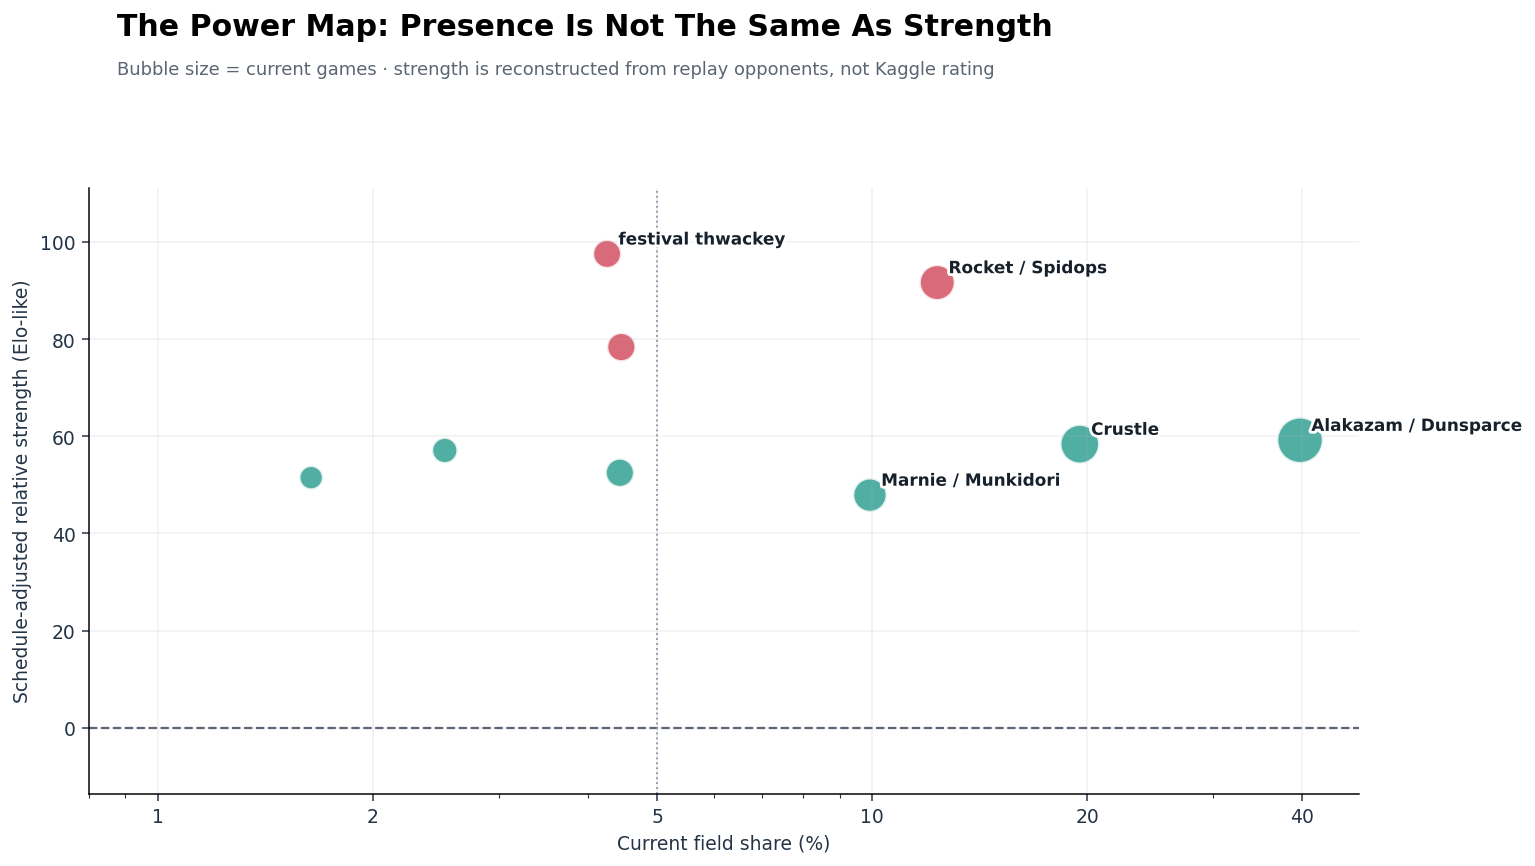

In [2]:
field = current.merge(
    strength.rename(columns={'entity': 'archetype'}), on='archetype', how='left', suffixes=('', '_strength')
)
field = field[(field['games'] >= 100) & field['strength_elo'].notna()].copy()
field['share_pct'] = field['usage_share'] * 100
field['label'] = field['archetype'].map(short_label)
field['size'] = 50 + 550 * np.sqrt(field['games'] / field['games'].max())

first_day = trend[trend['date'] == trend['date'].min()].set_index('archetype')['usage_share']
last_day = trend[trend['date'] == trend['date'].max()].set_index('archetype')['usage_share']
movement = pd.concat([first_day.rename('first'), last_day.rename('last')], axis=1).fillna(0)
movement['delta'] = movement['last'] - movement['first']
center_id = last_day.idxmax()
riser_id = movement['delta'].idxmax()
power_row = shortlist.sort_values(['strength_elo', 'high_strength_score_rate'], ascending=False).iloc[0]
weekly_stats = [
    ('🎯', 'Field center', f"{last_day.get(center_id, 0):.1%}",
     short_label(center_id), '#d1495b'),
    ('📈', 'Fastest riser', f"{movement.loc[riser_id, 'delta'] * 100:+.1f} pp",
     short_label(riser_id), '#2a9d8f'),
    ('⚡', 'Exact-list power leader', f"{power_row['strength_elo']:+.0f}",
     f"{short_label(power_row['archetype'])} · {str(power_row['entity'])[:8]}", '#6a4c93'),
]
cards = ''.join(
    f"""<div style="flex:1;min-width:190px;border-left:5px solid {color};background:#f7f9fc;
        padding:12px 15px;border-radius:6px;box-sizing:border-box">
        <div style="font-size:13px;color:#5b6573">{icon} {label}</div>
        <div style="font-size:25px;font-weight:700;color:#17212b;line-height:1.25">{value}</div>
        <div style="font-size:12px;color:#5b6573">{note}</div></div>"""
    for icon, label, value, note, color in weekly_stats
)
display(HTML(f'<div style="display:flex;gap:12px;flex-wrap:wrap;margin:6px 0 18px">{cards}</div>'))

fig, ax = plt.subplots(figsize=(11.5, 6.5), facecolor='#ffffff')
colors = np.where(field['strength_elo'] >= 75, '#d1495b',
         np.where(field['strength_elo'] >= 25, '#2a9d8f', '#457b9d'))
ax.scatter(field['share_pct'], field['strength_elo'], s=field['size'], c=colors,
           alpha=0.82, edgecolor='white', linewidth=1.4)
ax.axhline(0, color='#5b6573', lw=1.2, ls='--')
ax.axvline(5, color='#8d99ae', lw=1.0, ls=':')
label_ids = list(current.nlargest(4, 'usage_share')['archetype'])
label_ids += [x for x in field.nlargest(2, 'strength_elo')['archetype'] if x not in label_ids]
for _, row in field[field['archetype'].isin(label_ids)].iterrows():
    offset = {
        'dragapult': (7, 12),
        "other:Cynthia's Gabite|Cynthia's Gible": (7, -13),
    }.get(row['archetype'], (6, 5))
    ax.annotate(row['label'], (row['share_pct'], row['strength_elo']), xytext=offset,
                textcoords='offset points', fontsize=9, weight='bold', color='#17212b',
                path_effects=[pe.withStroke(linewidth=3, foreground='white')])
ax.set_xscale('log')
ax.set_xticks([1, 2, 5, 10, 20, 40], ['1', '2', '5', '10', '20', '40'])
ax.set_xlim(0.8, 48)
ax.set_xlabel('Current field share (%)')
ax.set_ylabel('Schedule-adjusted relative strength (Elo-like)')
fig.suptitle('The Power Map: Presence Is Not The Same As Strength', x=0.08, y=0.98,
             ha='left', fontsize=16, weight='bold')
fig.text(0.08, 0.91,
         'Bubble size = current games · strength is reconstructed from replay opponents, not Kaggle rating',
         color='#5b6573', fontsize=9.5)
ax.margins(x=0.08, y=0.14)
plt.tight_layout(rect=[0, 0, 1, 0.86])
plt.show()


## 📖 The Week's Story

- 🏛️ **The center held:** Alakazam stayed between 35.7% and 46.4% of the daily field and closed at 39.7% with a near-neutral 50.1% score rate.
- 🧱 **The wall wave receded:** Crustle peaked at 28.0% on July 12, then fell to 19.5% and a 46.7% score rate by July 16.
- 🕸️ **A pressure shell scaled quickly:** Team Rocket Spidops expanded by 10.9 percentage points across the window while remaining above 52% on the final day.
- 🌿 **Festival added a second pressure lane:** it appeared suddenly, peaked at 7.2%, and retained a positive result as the field began adapting.
- 🔄 **Marnie split into different trajectories:** Marnie/Munkidori recovered to 9.9% and 51.8%, while Marnie/Grimmsnarl fell to 1.6% and 44.9%.

> 🧭 **Weekly read:** presence, schedule-adjusted deck power, and policy quality moved together in a few places this week, but not everywhere.

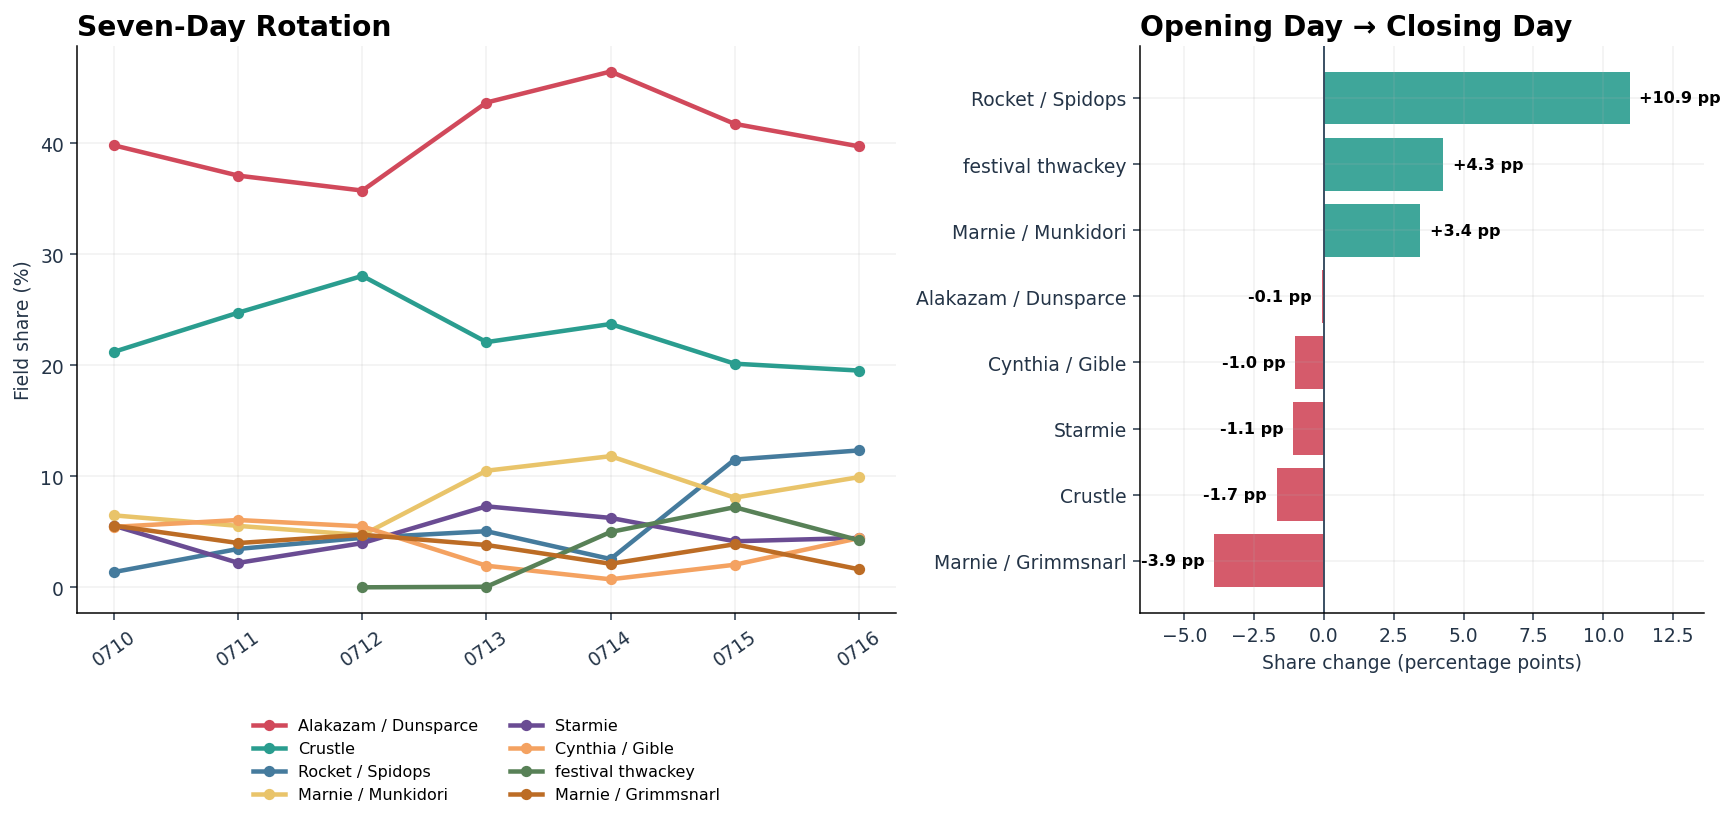

In [3]:
latest_date = trend['date'].max()
first_date = trend['date'].min()
latest = trend[trend['date'] == latest_date].set_index('archetype')['usage_share']
first = trend[trend['date'] == first_date].set_index('archetype')['usage_share']
movement = pd.concat([first.rename('first'), latest.rename('last')], axis=1).fillna(0)
movement['delta'] = movement['last'] - movement['first']
focus = list(latest.nlargest(6).index)
for x in JOURNAL_CONFIG.get('trend_focus', []):
    if x in latest.index and x not in focus:
        focus.append(x)
focus += [x for x in movement['delta'].abs().nlargest(4).index if x not in focus]
focus = focus[:8]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6.3), gridspec_kw={'width_ratios': [1.45, 1]})
palette = ['#d1495b', '#2a9d8f', '#457b9d', '#e9c46a', '#6a4c93', '#f4a261', '#588157', '#bc6c25']
for color, archetype in zip(palette, focus):
    rows = trend[trend['archetype'] == archetype].sort_values('date')
    ax1.plot(rows['date'].astype(str).str[-4:], rows['usage_share'] * 100, marker='o', lw=2.4,
             ms=5, color=color, label=short_label(archetype))
ax1.set_ylabel('Field share (%)')
ax1.set_title('Seven-Day Rotation', loc='left', fontsize=15)
ax1.tick_params(axis='x', rotation=35)
ax1.legend(frameon=False, fontsize=8.5, ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.16))

movers = movement.loc[focus].sort_values('delta')
bar_colors = ['#d1495b' if value < 0 else '#2a9d8f' for value in movers['delta']]
ax2.barh([short_label(x) for x in movers.index], movers['delta'] * 100, color=bar_colors, alpha=0.9)
ax2.axvline(0, color='#34495e', lw=1)
for idx, value in enumerate(movers['delta'] * 100):
    ax2.text(value + (0.35 if value >= 0 else -0.35), idx, f'{value:+.1f} pp',
             ha='left' if value >= 0 else 'right', va='center', fontsize=8.5, weight='bold')
ax2.set_title('Opening Day → Closing Day', loc='left', fontsize=15)
ax2.set_xlabel('Share change (percentage points)')
ax2.margins(x=0.18)
plt.tight_layout()
plt.show()


## 🧠 Why The Field Moved

- 🕸️ **Spidops attacked both major pillars.** It scored 54.3% against Alakazam and about 61% against Crustle in the July 16 matrix, giving players a reason to move away from pure wall mirrors.
- 🌿 **Festival punished slower setups.** It scored 53.2% against Alakazam and 60.5% against Crustle, although its small samples against several fringe decks still require caution.
- ⭐ **Starmie created a sharper counter-pressure lane.** It scored 69.1% against Crustle and 87.0% against Spidops on the current day, while losing the larger Alakazam matchup at 40.5%.
- 🏛️ **Alakazam survived through breadth rather than dominance.** It remained slightly favorable into Crustle and clearly favorable into Starmie and Cynthia, but lost to Spidops, Festival, Dragapult, and Marnie/Munkidori.
- 🧱 **Crustle's decline was matchup-shaped, not merely fashionable.** Its largest new pressure lanes were unfavorable, even though it still handled Dragapult well.

These are mechanism-based interpretations of the observed rotation, not claims that a single card or matchup caused the entire field to move.

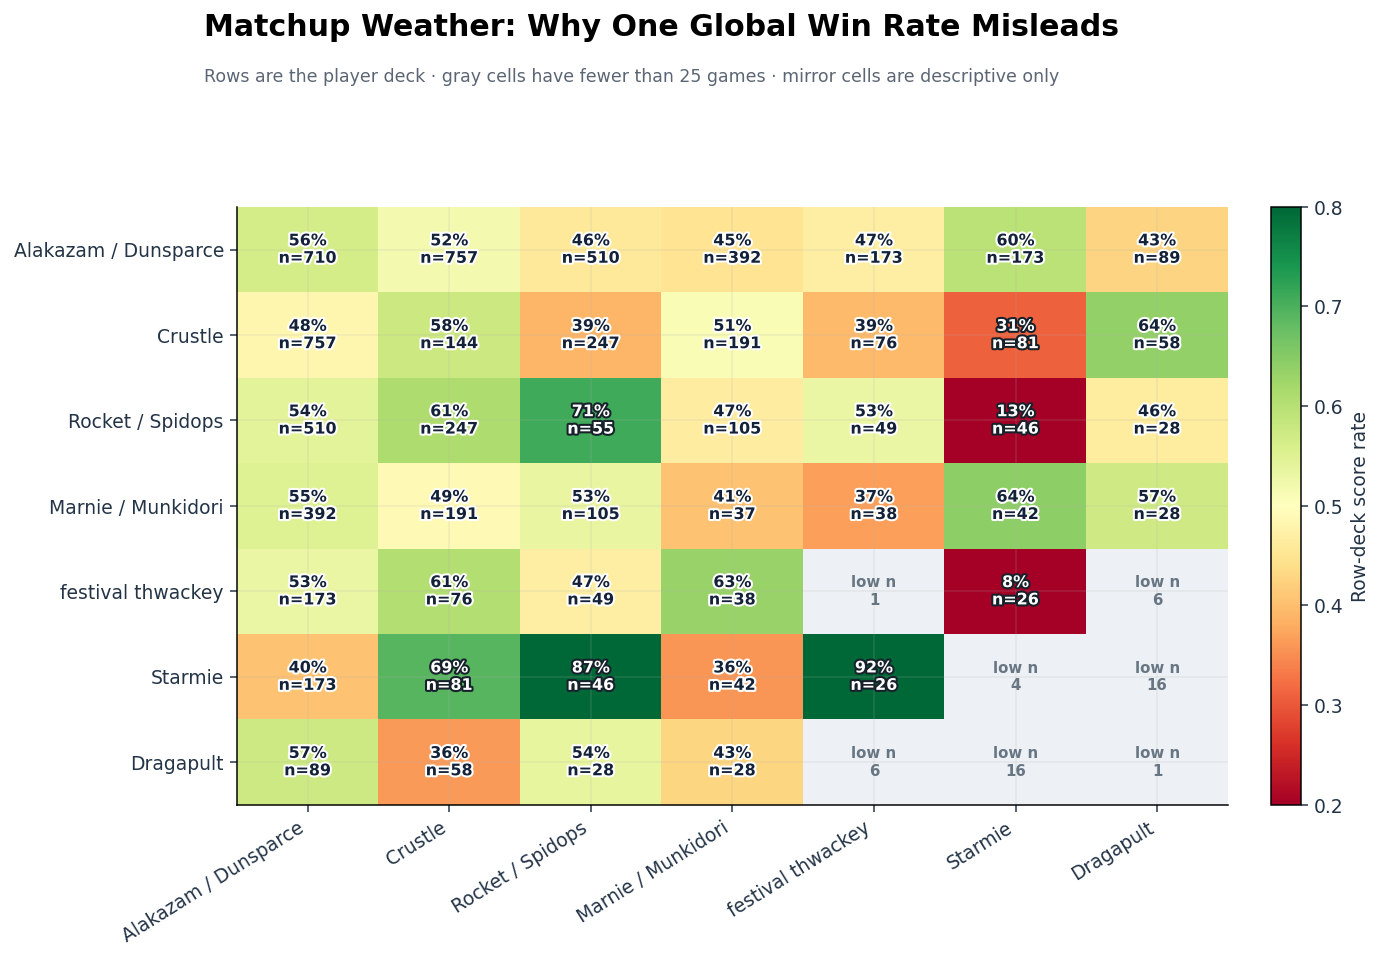

In [4]:
configured_focus = JOURNAL_CONFIG.get('matchup_focus', [])
available = set(current['archetype'])
latest_top = [x for x in configured_focus if x in available]
if not latest_top:
    latest_top = current.nlargest(6, 'games')['archetype'].tolist()
matrix = pd.DataFrame(np.nan, index=latest_top, columns=latest_top)
counts = pd.DataFrame(0, index=latest_top, columns=latest_top)
for _, row in matchups.iterrows():
    a, b = row['archetype_a'], row['archetype_b']
    if a not in matrix.index or b not in matrix.columns:
        continue
    rate, games = float(row['a_score_rate']), int(row['games'])
    matrix.loc[a, b], counts.loc[a, b] = rate, games
    if a != b:
        matrix.loc[b, a], counts.loc[b, a] = 1 - rate, games
for archetype in latest_top:
    if pd.isna(matrix.loc[archetype, archetype]):
        matrix.loc[archetype, archetype] = 0.5

display_matrix = matrix.where(counts >= 25)
cmap = plt.get_cmap('RdYlGn').copy()
cmap.set_bad('#edf1f5')
fig, ax = plt.subplots(figsize=(10.4, 7.2), facecolor='#ffffff')
image = ax.imshow(display_matrix.values, cmap=cmap, vmin=0.2, vmax=0.8, aspect='auto')
labels = [short_label(x) for x in latest_top]
ax.set_xticks(range(len(labels)), labels, rotation=32, ha='right')
ax.set_yticks(range(len(labels)), labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        value = matrix.iloc[i, j]
        if pd.isna(value):
            continue
        n = int(counts.iloc[i, j])
        if n < 25:
            ax.text(j, i, f'low n\n{n}', ha='center', va='center', fontsize=8,
                    weight='bold', color='#687684')
            continue
        rgba = image.cmap(image.norm(value))
        luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
        color = '#132238' if luminance > 0.62 else '#ffffff'
        halo = '#ffffff' if luminance > 0.62 else '#17212b'
        text = f'{value:.0%}' + (f'\nn={n}' if n else '')
        ax.text(j, i, text, ha='center', va='center', fontsize=8.5, weight='bold', color=color,
                path_effects=[pe.withStroke(linewidth=2.2, foreground=halo)])
fig.suptitle('Matchup Weather: Why One Global Win Rate Misleads', x=0.15, y=0.98,
             ha='left', fontsize=16, weight='bold')
fig.text(0.15, 0.91,
         'Rows are the player deck · gray cells have fewer than 25 games · mirror cells are descriptive only',
         color='#5b6573', fontsize=9.3)
fig.colorbar(image, ax=ax, fraction=0.035, pad=0.04, label='Row-deck score rate')
plt.tight_layout(rect=[0, 0, 1, 0.86])
plt.show()


## ⚔️ Matchup of the Week — The Old Center Meets the New Pressure Lanes

- 🟢 **Spidops found both centers:** 54.3% against Alakazam over 510 games and about 61% against Crustle over 247 games.
- ⭐ **Starmie checked the pressure shell:** 87.0% against Spidops over 46 games and 69.1% against Crustle over 81 games.
- 🏛️ **Alakazam still controlled selected lanes:** 59.5% against Starmie and 63.9% against Cynthia/Gible.
- 🐉 **Dragapult remained strategically awkward:** it beat Alakazam in the observed matrix but lost clearly to Crustle, preserving a rock-paper-scissors shape rather than one universal best deck.
- ⚠️ **Sample size still matters:** Festival versus Starmie was extremely one-sided, but only 26 games were observed.

> 🎯 **Strategic implication:** The current field rewards a portfolio of pressure and counter-pressure plans. Archetype labels alone are not enough; the exact list and the policy must survive the relevant matchup triangle.

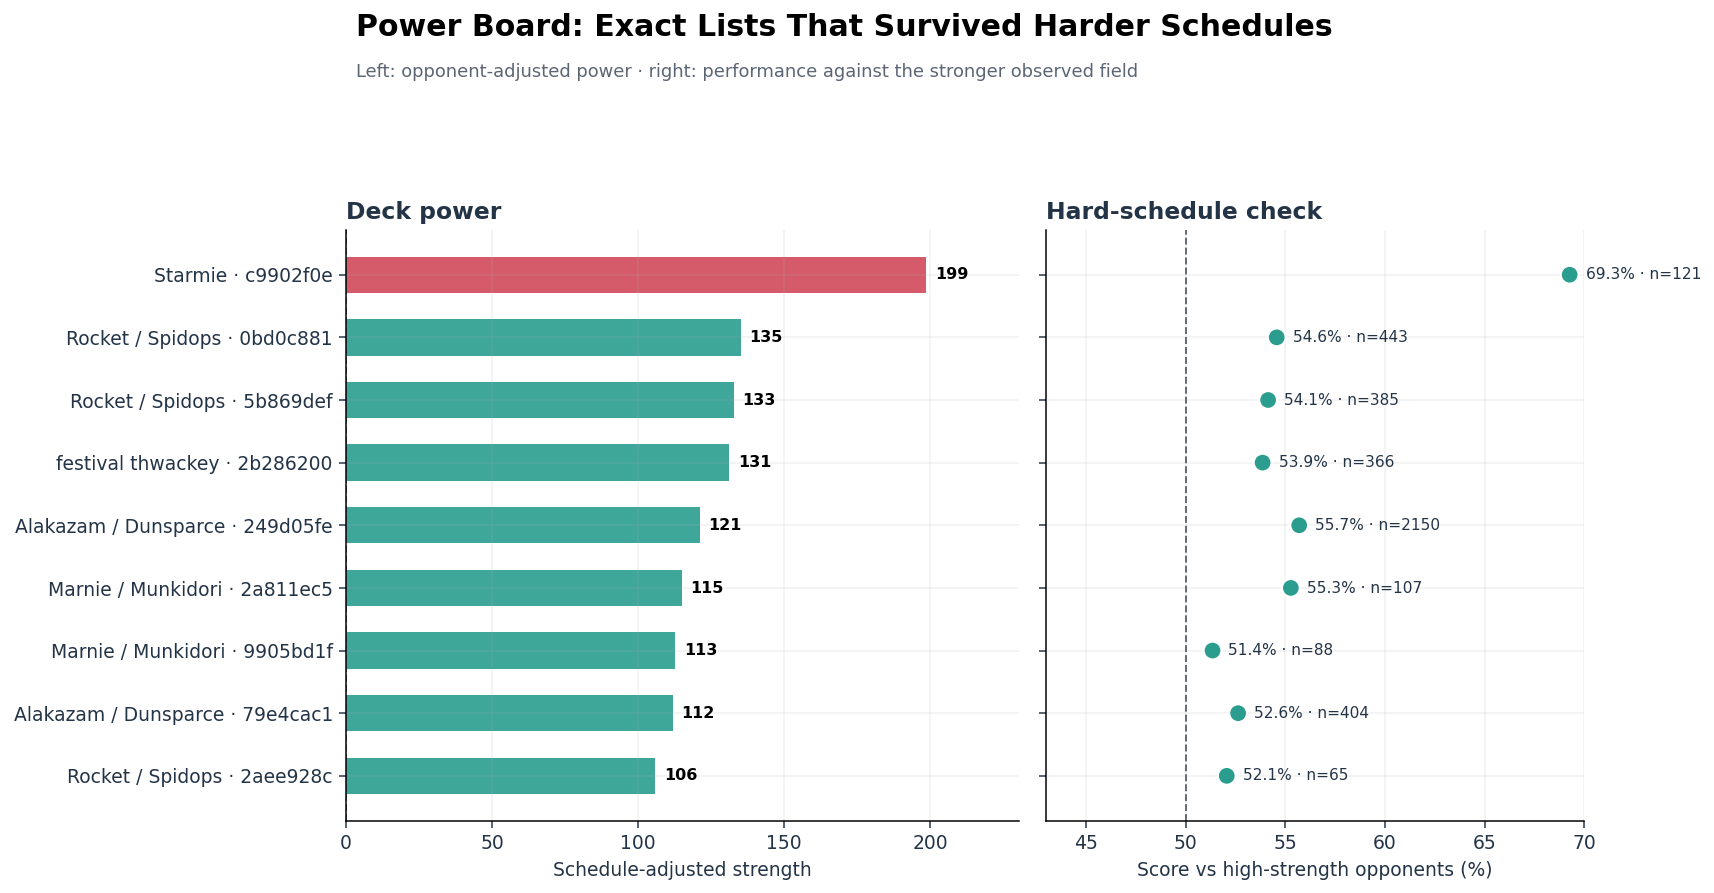

In [5]:
board = shortlist[shortlist['current_games'] >= 25].head(9).copy().iloc[::-1]
board['label'] = board['archetype'].map(short_label) + ' · ' + board['entity'].str[:8]
labels = board['label'].tolist()
y = np.arange(len(board))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.8, 6.7), sharey=True,
                               gridspec_kw={'width_ratios': [1.25, 1]}, facecolor='#ffffff')
strength_colors = ['#d1495b' if value >= 140 else '#2a9d8f' if value >= 100 else '#457b9d'
                   for value in board['strength_elo']]
ax1.barh(y, board['strength_elo'], color=strength_colors, alpha=0.9, height=0.58)
ax1.set_yticks(y, labels)
ax1.axvline(0, color='#5b6573', lw=1, ls='--')
for idx, value in enumerate(board['strength_elo']):
    ax1.text(value + 3, idx, f'{value:.0f}', va='center', fontsize=8.5, weight='bold')
ax1.set_xlabel('Schedule-adjusted strength')
ax1.set_title('Deck power', loc='left', fontsize=12.5, color='#243447')
ax1.margins(x=0.16)

rates = board['high_strength_score_rate'] * 100
rate_colors = ['#2a9d8f' if value >= 50 else '#d1495b' for value in rates]
ax2.scatter(rates, y, s=92, c=rate_colors, edgecolor='white', linewidth=1.2, zorder=3)
ax2.axvline(50, color='#5b6573', lw=1, ls='--')
for idx, (_, row) in enumerate(board.iterrows()):
    ax2.text(row['high_strength_score_rate'] * 100 + 0.8, idx,
             f"{row['high_strength_score_rate']:.1%} · n={int(row['current_games'])}",
             va='center', fontsize=8.2, color='#243447')
ax2.set_xlim(43, 70)
ax2.set_xlabel('Score vs high-strength opponents (%)')
ax2.set_title('Hard-schedule check', loc='left', fontsize=12.5, color='#243447')
fig.suptitle('Power Board: Exact Lists That Survived Harder Schedules', x=0.21, y=0.98,
             ha='left', fontsize=16, weight='bold')
fig.text(0.21, 0.91,
         'Left: opponent-adjusted power · right: performance against the stronger observed field',
         color='#5b6573', fontsize=9.5)
plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()


## 🌱 Emerging Challenger — Starmie

- ⭐ **Exact-list signal:** deck `c9902f0e` led the current reliable deck table at +198.7 schedule-adjusted strength, with 69.3% against high-strength opponents.
- 📊 **Field confirmation:** Starmie closed the window at 4.5% share and a 55.0% score rate, so the signal was not confined to a single isolated replay.
- ⚔️ **Matchup shape:** the shell pressured Crustle and Spidops strongly but remained vulnerable to the large Alakazam center.
- 🤖 **Policy result:** the best stable reconstructed Starmie pilot reached an 81.1% field-weighted holdout score locally, below the 86.5% Lucario reference and with overlapping uncertainty.
- 🧪 **Research status:** Starmie is the strongest current policy-development target, not a proven replacement for the mature references.

> 🧪 **Evidence status:** Strong deck signal and the most stable new policy candidate in the latest confirmation run. Reference supremacy and exact-panel coverage remain unresolved.

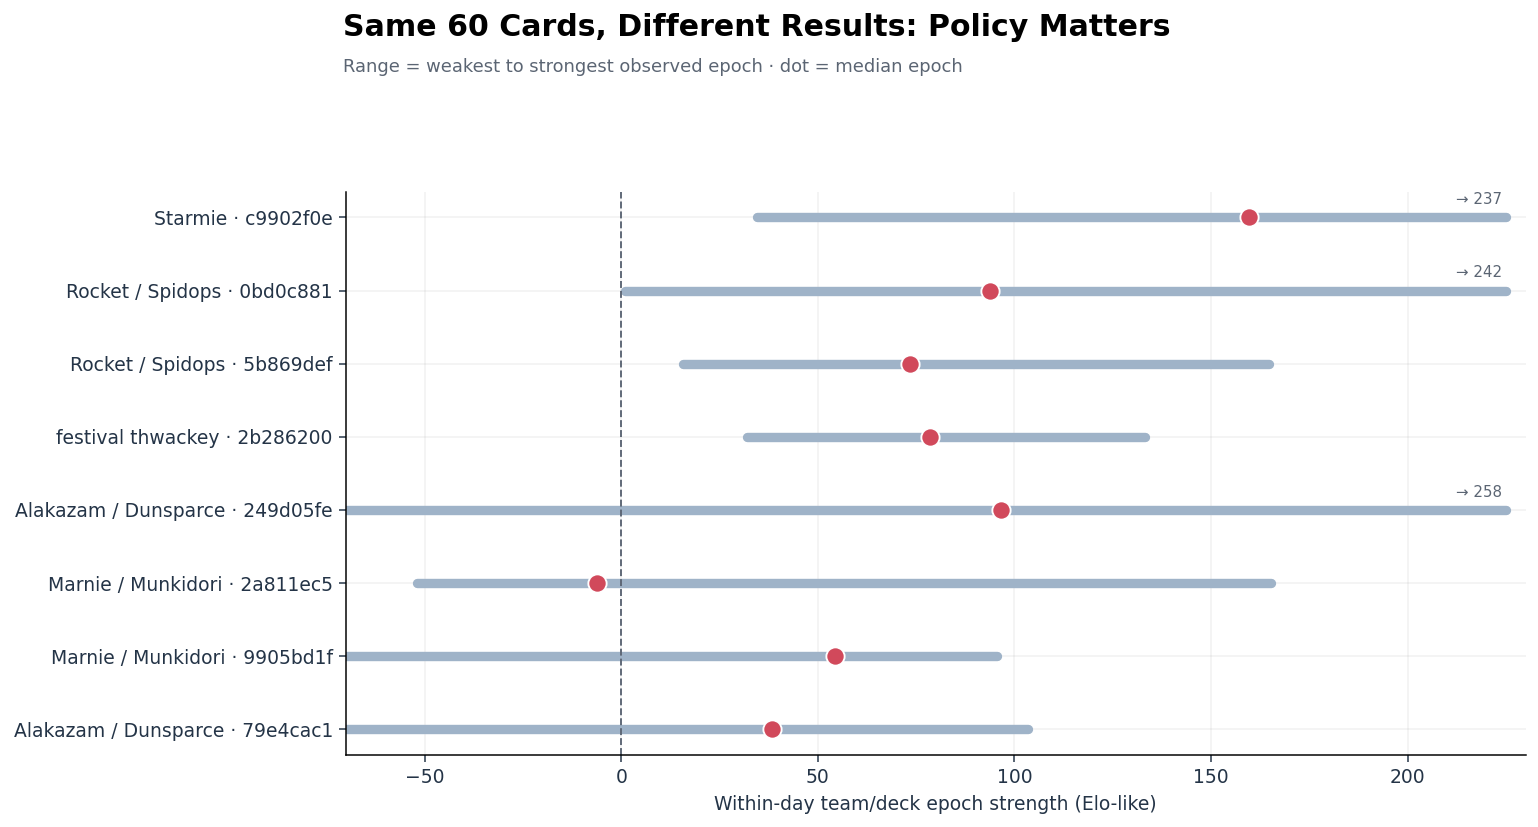

Exact-deck signal,Field evidence,Pilot evidence,Interpretation
Starmie c9902f0e,+198.7 strength; 69.3% vs hard field,p006 81.1% weighted holdout,Best new policy target; supremacy unresolved
Rocket Spidops 0bd0c881,+135.2 strength; 54.6% vs hard field,Current local policies remain polarized,Strong field deck; incomplete adoption policy
Festival 2b286200,+131.2 strength; 53.9% vs hard field,No current submit-grade pilot,Priority pilot-acquisition target
Alakazam 249d05fe,+121.1 strength across the field center,Mature reference family available,"Stable benchmark anchor, not an unchecked winner"


In [6]:
epoch = shortlist[
    (shortlist['current_games'] >= 25)
    & shortlist['epoch_strength_min'].notna()
    & shortlist['epoch_strength_max'].notna()
].head(8).copy().iloc[::-1]
epoch['label'] = epoch['archetype'].map(short_label) + ' · ' + epoch['entity'].str[:8]
fig, ax = plt.subplots(figsize=(11.5, 6.2))
xmin, xmax = -70, 225
for y, (_, row) in enumerate(epoch.iterrows()):
    left = max(float(row['epoch_strength_min']), xmin)
    right = min(float(row['epoch_strength_max']), xmax)
    ax.plot([left, right], [y, y], color='#9fb3c8', lw=5,
            solid_capstyle='round')
    ax.scatter(row['epoch_strength_median'], y, s=95, color='#d1495b', edgecolor='white', zorder=3)
    if row['epoch_strength_max'] > xmax:
        ax.annotate(f"→ {row['epoch_strength_max']:.0f}", (xmax, y), xytext=(-2, 7),
                    textcoords='offset points', ha='right', fontsize=8, color='#5b6573')
ax.axvline(0, color='#5b6573', lw=1, ls='--')
ax.set_xlim(xmin, xmax + 5)
ax.set_yticks(range(len(epoch)), epoch['label'])
ax.set_xlabel('Within-day team/deck epoch strength (Elo-like)')
fig.suptitle('Same 60 Cards, Different Results: Policy Matters', x=0.225, y=0.98,
             ha='left', fontsize=16, weight='bold')
fig.text(0.225, 0.91, 'Range = weakest to strongest observed epoch · dot = median epoch',
         color='#5b6573', fontsize=9.5)
plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

pilot_table = pd.DataFrame(JOURNAL_CONFIG['pilot_ledger'])
display(pilot_table.style.hide(axis='index').set_properties(**{'text-align': 'left', 'padding': '7px'}))


## 🎮 Same Deck, Different Results

- 🎴 **Deck strength and agent strength remain different quantities.** A strong replay list identifies a promising search region, not a ready submission.
- ⭐ **Starmie improved the transfer result.** Pilot p006 retained 81.1% after focused holdout, while p005 fell from 89.2% at selection to 78.1% on confirmation.
- 📉 **The p005 drop is a textbook selection effect.** Choosing the largest score from a wide search overstated its likely repeat performance by 11.1 percentage points.
- 🧩 **Coverage still limits confidence.** The exact selected panel represented 82.8% of current field weight; Marnie/Munkidori, Cynthia/Gible, and Dragapult remained fidelity gaps.
- ⚖️ **The reference intervals overlap the challenger.** The evidence supports continued testing, not a claim that the new policy is already superior.

> 💡 **Bottom line:** deck discovery identifies *what deserves attention*; it does not establish a fixed agent strength by itself.

## 🔬 What The Data Corrected

- 👓 **First impression:** the fastest route appeared to be selecting the highest-scoring Starmie policy from the wide search.
- 🔁 **What confirmation changed:** p005 regressed by 11.1 percentage points, while p006 was lower initially but much more stable.
- 🧭 **What exact binding changed:** apparent panel coverage above 90% fell to 82.8% when the benchmark was tied to the exact pilot builds that actually played.
- ⚖️ **What the references showed:** mature Lucario and Archaludon policies remained competitive or stronger under the same confirmation panel.
- 📌 **Revised conclusion:** publish the best available validated packages only with explicit uncertainty, and keep the next untouched date for a cleaner promotion test.

| Hypothesis | Test | Result | Decision |
|:--|:--|:--|:--|
| The wide-search winner will remain best on confirmation | Re-run Starmie p005 and p006 against a larger exact panel | p005 fell from 89.2% to 78.1%; p006 held near 81.1% | Prefer stability and independent holdout over the selection maximum |
| Nominal archetype coverage is enough | Bind every field row to the exact pilot build used in the benchmark | Validated field weight was 82.8%, not the nominal value above 90% | Use exact-build coverage for all promotion claims |
| The strongest new candidate clearly beats the references | Compare all candidates in the same 2,160-game confirmation run | Lucario led at 86.5%; Starmie p006 reached 81.1% with overlapping intervals | No proven replacement; expose only as an approved current-best challenger |

## 🔭 Next Week Watchlist

1. Check whether Team Rocket Spidops can hold double-digit share once Starmie and Festival receive better pilots.
2. Acquire a faithful Festival policy before treating its field rise as a locally reproducible option.
3. Repair exact-deck Marnie/Munkidori, Cynthia/Gible, and Dragapult pilots to close the remaining 17.2% panel gap.
4. Keep the next daily corpus untouched until candidate and opponent-pilot choices are frozen.
5. Re-test Starmie p006 against the repaired panel; retire p005 unless its policy changes materially.

These are conditional signals to monitor, not point forecasts.

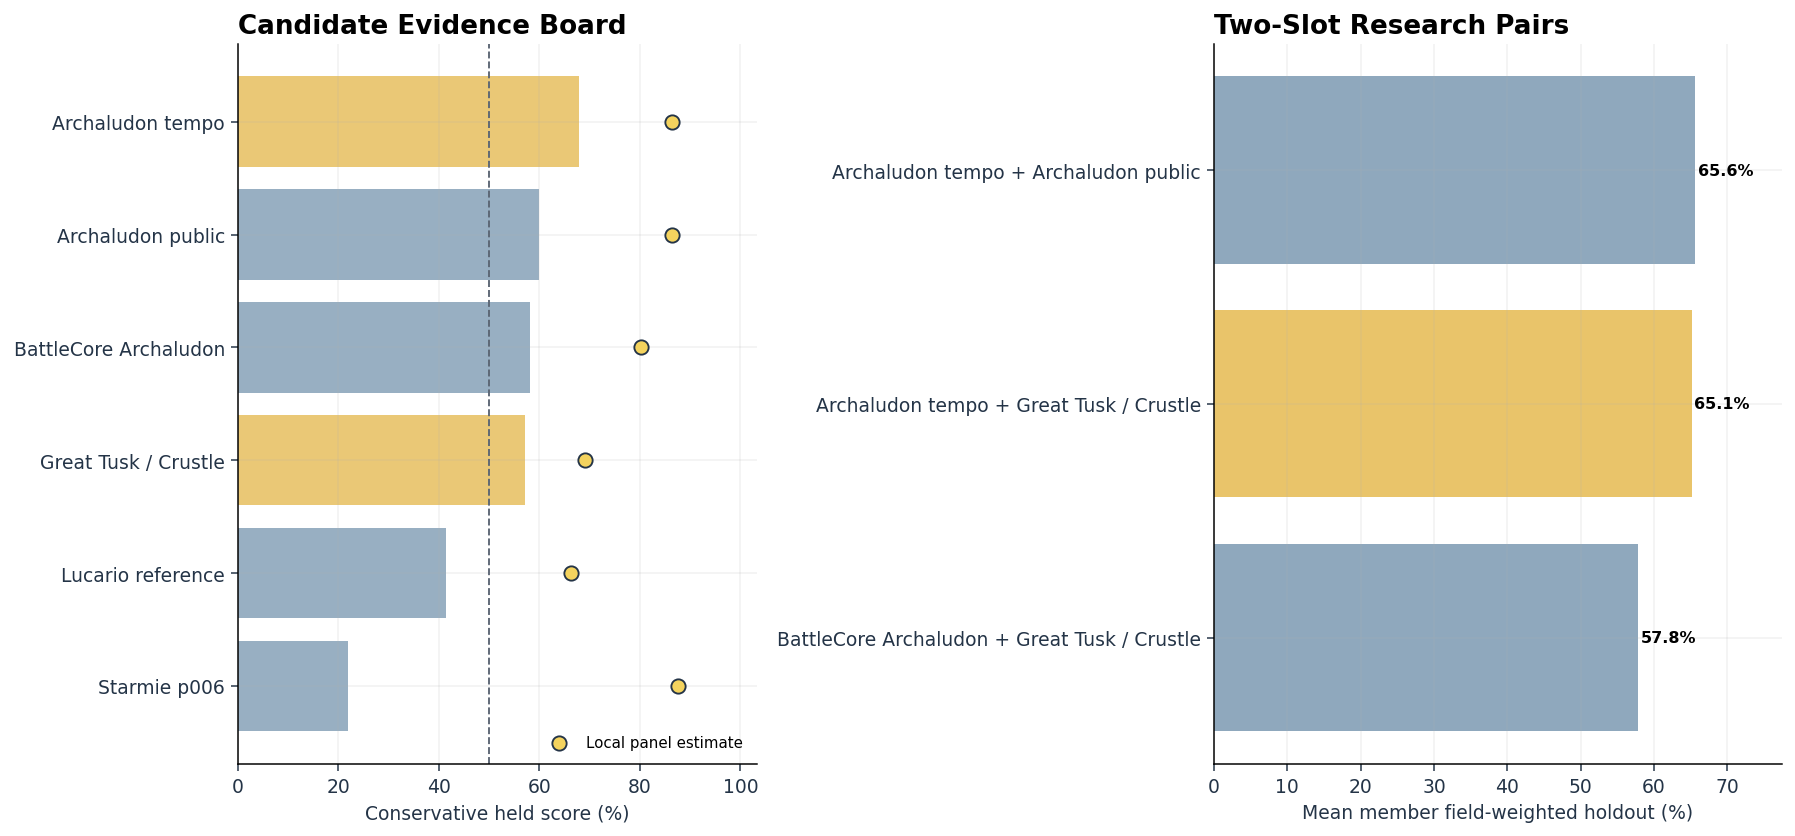

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.4, 6.3), gridspec_kw={'width_ratios': [1.05, 1.15]})
cand = candidates.sort_values('held_score').copy()
cand['label'] = cand['candidate_id'].map(candidate_label)
bar_colors = [
    '#e9c46a' if 'CURRENT_SELECTOR' in str(x)
    else '#2a9d8f' if str(x).startswith('PROMOTE')
    else '#8fa8bd'
    for x in cand['decision']
]
ax1.barh(cand['label'], cand['held_score'] * 100, color=bar_colors, alpha=0.92)
ax1.scatter(cand['panel_score'] * 100, cand['label'], color='#f4d35e', edgecolor='#243447', s=58, zorder=3)
ax1.axvline(50, color='#5b6573', ls='--', lw=1)
ax1.set_xlabel('Conservative held score (%)')
ax1.set_title('Candidate Evidence Board', loc='left', fontsize=14)
ax1.legend(['Local panel estimate'], frameon=False, loc='lower right', fontsize=8)
ax1.margins(x=0.18)

pair_plot = pairs.sort_values('pair_held_score').copy()
pair_plot['label'] = pair_plot['pair_key'].map(lambda key: ' + '.join(candidate_label(x) for x in key.split(';')))
pair_colors = [
    '#e9c46a' if str(decision).startswith('SELECTED_PAIR')
    else '#2a9d8f' if str(decision).startswith('PROMOTE')
    else '#8fa8bd'
    for decision in pair_plot['decision']
]
ax2.barh(pair_plot['label'], pair_plot['pair_held_score'] * 100, color=pair_colors)
for y, value in enumerate(pair_plot['pair_held_score'] * 100):
    ax2.text(value + 0.4, y, f'{value:.1f}%', va='center', fontsize=8.5, weight='bold')
ax2.set_xlabel('Mean member field-weighted holdout (%)')
ax2.set_title('Two-Slot Research Pairs', loc='left', fontsize=14)
ax2.margins(x=0.18)
plt.tight_layout()
plt.show()


## 🎯 Agent Board

- 🅰️ **Archaludon Metal Tempo:** independent strong-panel leader at 67.9%, with a 58.7% Wilson lower bound and the highest schedule-adjusted rating in the comparison.
- 🅱️ **Great Tusk / Crustle Library-Out:** 57.1% against the same strong panel and the best strategically distinct complement to the Metal-tempo leader.
- 🧩 **Portfolio evidence:** the pair reached a 74.0% opponent-level best-member score; both policies supplied unique matchup edges and no shared tested opponent fell below 50%.
- 🔍 **Why proxy leaders were not selected:** the latest Lucario and Starmie options fell to 41.4% and 21.9% in the independent strong-agent panel despite much stronger proxy scores.
- ⚖️ **Evidence boundary:** the engine does not expose a reproducible seed, so this is independent unpaired confirmation rather than common-random-number evidence.

> 📌 **Evidence rule:** a strong exact list becomes agent-strength evidence only after its policy clears independent holdout, matchup-direction, runtime, and package checks.

## 🎒 Agent Profiles

Two package-validated profiles are available. Profile A is the strongest current independent-panel policy. Profile B is the highest-ranked complement with a different control and library-pressure plan. Selection follows the current agent benchmark and portfolio evidence rather than historical live rating.

Use `AGENT_SELECTION` below to choose one listed profile. Running the notebook writes `submission.tar.gz`.

In [8]:
# 🎯 Choose one benchmark-confirmed profile and rerun the notebook to build submission.tar.gz.
# 🅰️ "A" = Archaludon Metal Tempo
#      ↳ primary strong-panel leader.
# 🅱️ "B" = Great Tusk / Crustle Library-Out
#      ↳ diversified library-out complement.

AGENT_SELECTION = "A"



In [9]:
selected_key = str(AGENT_SELECTION).strip().upper()
if selected_key not in AGENT_PAYLOADS:
    raise ValueError(f'Unknown AGENT_SELECTION={AGENT_SELECTION!r}; choose one of {sorted(AGENT_PAYLOADS)}')
profile = AGENT_PAYLOADS[selected_key]
msg = (
    f"### 🎒 Selected profile: `{selected_key}` — {profile['name']}\n\n"
    f"**Role:** {profile['role']}  \n"
    f"**Evidence:** {profile['evidence']}  \n"
    f"**Strict status:** {profile['strict_status']}  \n"
    f"`main.py` sha256 `{profile['main_sha256'][:12]}` · "
    f"`deck.csv` sha256 `{profile['deck_sha256'][:12]}`"
)
display(Markdown(msg))

### 🎒 Selected profile: `A` — Archaludon Metal Tempo

**Role:** primary strong-panel leader  
**Evidence:** 67.9% over 112 independent strong-panel games; Wilson lower bound 58.7%; strength-adjusted Elo +106.7.  
**Strict status:** CURRENT_STRONG_PANEL_LEADER; package revalidation required after embedding  
`main.py` sha256 `a4c53101be30` · `deck.csv` sha256 `fbe6ab599922`

## 📦 Submission Package

The selected profile is compiled, checked for a 60-card deck and callable agent hook, and packaged with the competition engine files as `submission.tar.gz`.

In [10]:
def _decode_payload_text(value):
    return base64.b64decode(value.encode('ascii'))

def _write_embedded_cg_wrappers(target_dir):
    for name, value in CG_PY_FILE_B64.items():
        (target_dir / name).write_bytes(base64.b64decode(value.encode('ascii')))

def _find_cg_source():
    env_dir = os.environ.get('PTCG_CG_DIR')
    exact_candidates = []
    if env_dir: exact_candidates.append(env_dir)
    exact_candidates.extend(['/kaggle/input/competitions/pokemon-tcg-ai-battle/sample_submission/cg','/kaggle/input/competitions/pokemon-tcg-ai-battle/sample_submission/sample_submission/cg','/kaggle/input/pokemon-tcg-ai-battle/sample_submission/cg','/kaggle/input/pokemon-tcg-ai-battle/sample_submission/sample_submission/cg'])
    parent_relative = []
    for base in [Path.cwd(), *Path.cwd().parents]:
        parent_relative.extend([base/'KaggleData'/'pokemon-tcg-ai-battle'/'sample_submission'/'cg', base/'KaggleData'/'pokemon-tcg-ai-battle'/'sample_submission'/'sample_submission'/'cg', base/'input'/'raw'/'pokemon-tcg-ai-battle'/'sample_submission'/'cg', base/'input'/'raw'/'pokemon-tcg-ai-battle'/'sample_submission'/'sample_submission'/'cg'])
    for raw in [*exact_candidates, *parent_relative]:
        p = Path(raw)
        if p.exists() and (p/'libcg.so').exists(): return p, 'official_or_local_sample_submission'
    for pattern in ['/kaggle/input/**/sample_submission/cg','/kaggle/input/**/sample_submission/sample_submission/cg','/kaggle/input/**/cg-lib/cg','/kaggle/input/**/cg','KaggleData/**/sample_submission/cg','KaggleData/**/sample_submission/sample_submission/cg','KaggleData/**/cg-lib/cg','KaggleData/**/cg','input/raw/**/sample_submission/cg','input/raw/**/sample_submission/sample_submission/cg','input/raw/**/cg-lib/cg','input/raw/**/cg']:
        for raw in glob.glob(pattern, recursive=True):
            p = Path(raw)
            if p.exists() and (p/'libcg.so').exists(): return p, 'glob_sample_submission'
    spec = importlib.util.find_spec('kaggle_environments')
    if spec and spec.submodule_search_locations:
        kg_root = Path(list(spec.submodule_search_locations)[0])
        p = kg_root/'envs'/'cabt'/'cg'
        if p.exists() and (p/'libcg.so').exists(): return p, 'kaggle_environments_cabt_binary_plus_embedded_wrappers'
    return None, None

def _purge_bytecode(path):
    for cache_dir in path.rglob('__pycache__'):
        shutil.rmtree(cache_dir, ignore_errors=True)
    for pyc in list(path.rglob('*.pyc')) + list(path.rglob('*.pyo')):
        try: pyc.unlink()
        except FileNotFoundError: pass

def _tar_filter(member):
    parts = Path(member.name).parts
    if '__pycache__' in parts or member.name.endswith(('.pyc', '.pyo')): return None
    if any(part.startswith('._') for part in parts) or any(part == '.DS_Store' for part in parts): return None
    return member

def _run_self_game_smoke(mod, build_dir, max_steps=600):
    from cg.game import battle_start, battle_select, battle_finish
    deck = [int(x) for x in (build_dir/'deck.csv').read_text().splitlines() if x.strip()]
    if len(deck) != 60: raise AssertionError(f'deck.csv contains {len(deck)} cards, expected 60')
    obs, _ = battle_start(deck, deck)
    if obs is None: raise AssertionError('battle_start returned no observation')
    steps = 0; terminal = False
    try:
        while steps < max_steps:
            if obs is None: terminal = True; break
            if not isinstance(obs, dict): raise AssertionError(f'observation should be dict, got {type(obs)!r}')
            select = obs.get('select')
            if not isinstance(select, dict): terminal = True; break
            options = select.get('option') or []
            if len(options) == 0: terminal = True; break
            try: action = mod.agent(obs, None)
            except TypeError: action = mod.agent(obs)
            if action is None: action = []
            if not isinstance(action, list) or not all(isinstance(i, int) for i in action): raise AssertionError(f'agent returned non-list[int]: {action!r}')
            min_count = int(select.get('minCount') or 0); max_count = int(select.get('maxCount') or len(options))
            if not (min_count <= len(action) <= max_count): raise AssertionError(f'agent selected {len(action)} choices but legal range is [{min_count}, {max_count}]')
            bad = [i for i in action if i < 0 or i >= len(options)]
            if bad: raise AssertionError(f'agent returned out-of-range option indices {bad}; option_count={len(options)}')
            obs = battle_select(action); steps += 1
    finally:
        battle_finish()
    return {'steps': steps, 'terminal_observed': terminal, 'max_steps': max_steps}

work_root = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd()
build_dir = work_root/'selected_agent_build'
if build_dir.exists(): shutil.rmtree(build_dir)
build_dir.mkdir(parents=True, exist_ok=True)
(build_dir/'main.py').write_bytes(_decode_payload_text(profile['main_b64']))
(build_dir/'deck.csv').write_bytes(_decode_payload_text(profile['deck_b64']))

for relative_name, encoded in profile.get('extra_files_b64', {}).items():
    relative_path = Path(relative_name)
    if relative_path.is_absolute() or '..' in relative_path.parts:
        raise ValueError(f'Unsafe embedded payload path: {relative_name!r}')
    target = build_dir / relative_path
    target.parent.mkdir(parents=True, exist_ok=True)
    target.write_bytes(_decode_payload_text(encoded))

cg_src, cg_mode = _find_cg_source()
if cg_src is None: raise ModuleNotFoundError('Could not locate cg/libcg.so. Attach the competition sample_submission input or run in a Kaggle image with cabt installed.')
shutil.copytree(cg_src, build_dir/'cg', dirs_exist_ok=True, ignore=shutil.ignore_patterns('__pycache__', '*.pyc', '*.pyo'))
if not all((build_dir/'cg'/f).exists() for f in ['api.py','game.py','sim.py']): _write_embedded_cg_wrappers(build_dir/'cg')
if not all((build_dir/'cg'/f).exists() for f in ['api.py','game.py','sim.py','libcg.so']):
    missing = [f for f in ['api.py','game.py','sim.py','libcg.so'] if not (build_dir/'cg'/f).exists()]
    raise FileNotFoundError(f'Incomplete cg package after copy; missing {missing}')
_purge_bytecode(build_dir)

deck_ids = [int(x) for x in (build_dir/'deck.csv').read_text().splitlines() if x.strip()]
assert len(deck_ids) == 60, f'deck length must be 60, got {len(deck_ids)}'
py_compile.compile(str(build_dir/'main.py'), doraise=True)

old_cwd = Path.cwd(); smoke_result = {'skipped': False}; sys.path.insert(0, str(build_dir))
try:
    os.chdir(build_dir)
    spec = importlib.util.spec_from_file_location('selected_main', build_dir/'main.py')
    mod = importlib.util.module_from_spec(spec); spec.loader.exec_module(mod)
    assert callable(getattr(mod, 'agent', None)), 'main.py must expose callable agent'
    initial_obs = {'select': None, 'logs': [], 'current': None, 'search_begin_input': None}
    try: initial_action = mod.agent(initial_obs, None)
    except TypeError: initial_action = mod.agent(initial_obs)
    assert initial_action == deck_ids, 'initial agent call must return the same 60 card IDs as deck.csv'
    smoke_result = _run_self_game_smoke(mod, build_dir)
finally:
    os.chdir(old_cwd)
    if str(build_dir) in sys.path: sys.path.remove(str(build_dir))

archive_path = work_root/'submission.tar.gz'
if archive_path.exists(): archive_path.unlink()
with tarfile.open(archive_path, 'w:gz') as tar:
    tar.add(build_dir/'main.py', arcname='main.py', filter=_tar_filter)
    tar.add(build_dir/'deck.csv', arcname='deck.csv', filter=_tar_filter)
    tar.add(build_dir/'cg', arcname='cg', filter=_tar_filter)
    for relative_name in profile.get('extra_files_b64', {}):
        tar.add(build_dir/relative_name, arcname=relative_name, filter=_tar_filter)
with tarfile.open(archive_path, 'r:gz') as tar:
    names = set(tar.getnames())
required = {'main.py','deck.csv','cg/api.py','cg/game.py','cg/sim.py'}
required.update(profile.get('extra_files_b64', {}).keys())
missing = sorted(required - names)
if missing: raise AssertionError(f'submission archive missing required files: {missing}')

pkg_info = {'selected': selected_key, 'profile': profile['name'], 'cg_mode': cg_mode, 'archive': str(archive_path), 'archive_bytes': archive_path.stat().st_size, 'build_dir': str(build_dir), 'deck_length': len(deck_ids), 'deck_unique_cards': len(set(deck_ids)), 'smoke_result': smoke_result}
display(Markdown(f"### ✅ Package built: `{archive_path.name}`\n\n- Selected: **{selected_key} — {profile['name']}**\n- Archive size: **{pkg_info['archive_bytes']:,} bytes**\n- cg source: `{cg_mode}`\n- Deck: **{pkg_info['deck_length']} cards**, {pkg_info['deck_unique_cards']} unique IDs\n- Self-game smoke: `{pkg_info['smoke_result']}`\n"))


### ✅ Package built: `submission.tar.gz`

- Selected: **A — Archaludon Metal Tempo**
- Archive size: **1,983,237 bytes**
- cg source: `official_or_local_sample_submission`
- Deck: **60 cards**, 16 unique IDs
- Self-game smoke: `{'steps': 138, 'terminal_observed': True, 'max_steps': 600}`
